In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

print("Imports OK")


Imports OK


In [2]:
# Root folder containing your *_features.csv files (searches recursively)
ROOT = r"/Users/margaridaseabra/Downloads/REM analysis-results"  # <-- change me
GLOB = "*_features.csv"

# Where to save results (set to None to default)
OUT_ROOT = r"/Users/margaridaseabra/Downloads/REM analysis-results" 


In [ ]:
def parse_mouse_cond(filename: str):
    """
    Robustly extract mouse and condition from a filename.

    Handles keywords anywhere in the name and maps common variants:
      baseline:  "baseline", "base"
      ambtemp:   "ambtemp", "ambient", "amb_temp", "roomtemp", "rt"
      drugs:     "drugs", "drug", common drug tags like "cno", "ket", "muscimol"
    Fallback: if no keyword match, tries the token right after 'mouse\\d+'.
    """
    fname = filename.lower()

    # ---- mouse ----
    mouse = "unknownMouse"
    m = re.search(r"(mouse\d+)", fname, flags=re.IGNORECASE)
    if m:
        mouse = m.group(1)

    # ---- condition (keyword-first) ----
    # define keyword buckets (add your lab's tags here if needed)
    baseline_kw = {"baseline", "base"}
    ambtemp_kw  = {"ambtemp", "ambient", "amb_temp"}
    drugs_kw    = {"drugs", "drug"}

    cond = None
    tokens = re.split(r"[^\w]+", fname)  # split on non-alphanumeric/underscore
    toks = set(t for t in tokens if t)   # unique tokens

    if toks & baseline_kw:
        cond = "baseline"
    elif toks & ambtemp_kw:
        cond = "ambtemp"
    elif toks & drugs_kw:
        cond = "drugs"

    # ---- fallback: take the chunk after mouseXX up to next '-' or '_' ----
    if cond is None and m:
        # find the substring after the mouse token
        start = m.end()
        tail = fname[start:]
        # take first chunk separated by '-' or '_' (e.g., "ambtemp_notched..." -> "ambtemp")
        m2 = re.match(r"[-_]*([a-z0-9]+)", tail)
        if m2:
            guess = m2.group(1)
            # map a few common guesses to canonical labels
            if guess in baseline_kw:
                cond = "baseline"
            elif guess in ambtemp_kw:
                cond = "ambtemp"
            elif guess in drugs_kw:
                cond = "drugs"
            else:
                cond = guess  # unknown tag, keep as-is

    if cond is None:
        cond = "unknownCond"

    return mouse, cond



def clean_numeric(df: pd.DataFrame):
    """
    - numeric-only
    - drop all-NaN & constant columns
    - median-impute NaNs
    - z-score columns
    Returns X (ndarray) and feature_names (list)
    """
    num = df.select_dtypes(include=[np.number]).copy()
    if num.empty:
        return np.empty((len(df), 0)), []
    keep = []
    for c in num.columns:
        s = num[c]
        if s.isna().all():
            continue
        if (np.nanmax(s.values) - np.nanmin(s.values)) == 0:
            continue
        keep.append(c)
    num = num[keep]
    if num.shape[1] == 0:
        return np.empty((len(df), 0)), []
    for c in num.columns:
        med = num[c].median(skipna=True)
        if pd.isna(med):
            med = 0.0
        num[c] = num[c].fillna(med)
    X = StandardScaler().fit_transform(num.values)
    return X, list(num.columns)


def run_pca_simple(X: np.ndarray):
    ncomp = min(X.shape[0], X.shape[1])
    pca = PCA(n_components=ncomp)
    scores = pca.fit_transform(X)         # samples x PCs
    loadings = pca.components_.T          # features x PCs
    explained = pca.explained_variance_ratio_ * 100.0
    return scores, loadings, explained


def scree_plot(explained, title):
    plt.figure()
    plt.plot(range(1, len(explained)+1), explained, marker='o')
    plt.xlabel("PC")
    plt.ylabel("Explained variance (%)")
    plt.title(title)
    plt.grid(True)
    plt.show()


def pc_scatter(scores, explained, labels, title):
    plt.figure()
    u = pd.unique(pd.Series(labels))
    for lab in u:
        mask = (labels == lab)
        plt.scatter(scores[mask, 0], scores[mask, 1], label=str(lab))
    xlab = f"PC1 ({explained[0]:.1f}%)" if len(explained) > 0 else "PC1"
    ylab = f"PC2 ({explained[1]:.1f}%)" if len(explained) > 1 else "PC2"
    plt.xlabel(xlab); plt.ylabel(ylab)
    plt.title(title)
    if len(u) <= 15:
        plt.legend(frameon=False, fontsize=8)
    plt.grid(True)
    plt.show()


def save_outputs(out_dir: Path, subset_name: str, scores, loadings, explained, feat_names, meta_df: pd.DataFrame):
    out_dir.mkdir(parents=True, exist_ok=True)
    # scores
    score_cols = [f"PC{i+1}" for i in range(scores.shape[1])]
    scores_df = pd.DataFrame(scores, columns=score_cols)
    for col in ["source_file", "mouse", "condition"]:
        scores_df.insert(0, col, meta_df[col].values)
    scores_df.to_csv(out_dir / "PCA_scores.csv", index=False)
    # loadings
    load_df = pd.DataFrame(loadings, columns=score_cols)
    load_df.insert(0, "feature", feat_names)
    load_df.to_csv(out_dir / "PCA_loadings.csv", index=False)
    # explained
    expl_df = pd.DataFrame({
        "PC": np.arange(1, len(explained)+1, dtype=int),
        "ExplainedPct": explained,
        "CumulativePct": np.cumsum(explained),
    })
    expl_df.to_csv(out_dir / "PCA_explained.csv", index=False)
    print(f"Saved: {out_dir}")

def top_loadings_table(loadings, feat_names, k=12):
    """
    Build a long table of top-|loading| features for each PC.
    Returns a DataFrame with columns: PC, feature, loading, abs_loading, rank.
    """
    pcs = loadings.shape[1]
    rows = []
    for pc in range(pcs):
        vec = loadings[:, pc]
        idx = np.argsort(np.abs(vec))[::-1][:k]
        for r, i in enumerate(idx, start=1):
            rows.append({
                "PC": pc+1,
                "feature": feat_names[i],
                "loading": float(vec[i]),
                "abs_loading": float(abs(vec[i])),
                "rank": r
            })
    return pd.DataFrame(rows)

def plot_top_loadings_bar(loadings, feat_names, pc=1, k=12, title_prefix=""):
    """
    Horizontal bar plot for the top-k features (by |loading|) on PC `pc`.
    """
    pc_idx = pc - 1
    vec = loadings[:, pc_idx]
    idx = np.argsort(np.abs(vec))[::-1][:k]
    feats = [feat_names[i] for i in idx][::-1]       # smallest at bottom -> largest on top after plotting
    vals  = [vec[i] for i in idx][::-1]

    plt.figure()
    plt.barh(range(len(vals)), vals)
    plt.yticks(range(len(vals)), feats)
    plt.xlabel("Loading (signed)")
    plt.title(f"{title_prefix} Top {k} features on PC{pc}")
    plt.grid(axis="x", linestyle=":")
    plt.tight_layout()
    plt.show()

def save_top_loadings_csv(out_dir, name, loadings, feat_names, k=12):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    tbl = top_loadings_table(loadings, feat_names, k=k)
    tbl.to_csv(out_dir / f"{name}_top_loadings.csv", index=False)
    return tbl

def top_features_overall(loadings, feat_names, top_n=20, pcs=None):
    """
    Pick the top-N features by max |loading| across selected PCs (default: all PCs).
    Returns indices and names (ordered by importance).
    """
    L = loadings if pcs is None else loadings[:, np.array(pcs)-1]
    scores = np.max(np.abs(L), axis=1)
    idx = np.argsort(scores)[::-1][:top_n]
    return idx, [feat_names[i] for i in idx]

def plot_pc_feature_heatmap(loadings, feat_names, title, out_path=None, top_n=20, pcs=None):
    """
    Heatmap of loadings (signed) for top-N features across selected PCs (default: all).
    - One figure only (no subplots).
    - Uses matplotlib imshow + colorbar.
    """
    if pcs is None:
        pcs = list(range(1, loadings.shape[1] + 1))
    pc_idx = np.array(pcs) - 1

    idx, feats = top_features_overall(loadings, feat_names, top_n=top_n, pcs=pcs)
    M = loadings[idx][:, pc_idx]   # shape: (features, PCs)

    plt.figure()
    im = plt.imshow(M, aspect='auto', cmap='bwr', origin='lower',
                    vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
    plt.colorbar(im, label='Loading (signed)')
    plt.yticks(range(len(feats)), feats)
    plt.xticks(range(len(pcs)), [f"PC{p}" for p in pcs], rotation=0)
    plt.title(f"{title} — Top {top_n} features")
    plt.xlabel("Principal Components")
    plt.ylabel("Features")
    plt.tight_layout()
    if out_path:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=200)
    plt.show()


def per_mouse_normalize(df: pd.DataFrame, exclude_cols=("source_file","mouse","condition"),
                        impute="median"):
    out = df.copy()
    # choose numeric feature columns (excluding metadata)
    num_cols = out.select_dtypes(include=[np.number]).columns.difference(exclude_cols, sort=False)

    # group by mouse, impute -> z-score
    for m, block in out.groupby("mouse"):
        idx = block.index
        X = block[num_cols].copy()

        # impute within mouse
        if impute == "median":
            fill = X.median(skipna=True)
        elif impute == "mean":
            fill = X.mean(skipna=True)
        else:
            fill = pd.Series(0.0, index=num_cols)  # fallback

        X = X.fillna(fill)

        # per-mouse z-score (protect zero-std)
        mu = X.mean()
        sd = X.std(ddof=0).replace(0, 1.0)
        out.loc[idx, num_cols] = (X - mu) / sd

    return out

def clean_numeric(df: pd.DataFrame, scale=True):
    """
    - keep numeric cols
    - drop all-NaN & constant cols
    - (if scale) StandardScaler across *all rows*
    """
    num = df.select_dtypes(include=[np.number]).copy()
    if num.empty:
        return np.empty((len(df), 0)), []
    keep = []
    for c in num.columns:
        s = num[c]
        if s.isna().all():  # all NaN
            continue
        if (np.nanmax(s.values) - np.nanmin(s.values)) == 0:  # constant
            continue
        keep.append(c)
    num = num[keep]
    if num.shape[1] == 0:
        return np.empty((len(df), 0)), []
    if scale:
        X = StandardScaler().fit_transform(num.values)
    else:
        # already normalized upstream (e.g., per-mouse z), just pass values
        X = num.values
    return X, list(num.columns)

def choose_n_pcs_by_cum(explained: np.ndarray, threshold: float = 80.0) -> int:
    """Return smallest n PCs whose cumulative explained variance >= threshold (%)"""
    cum = np.cumsum(explained)
    if len(cum) == 0:
        return 0
    n = int(np.searchsorted(cum, threshold) + 1)
    return min(max(n, 1), len(cum))


def plot_pc_pair_grid(scores: np.ndarray, explained: np.ndarray, labels,
                      pcs: list = None, per_row: int = 3, figsize=(12, 8)):
    """
    Plot multiple scatter panels of PC pairs.
    - If `pcs` is None: choose PCs up to the number required to reach 80% cumulative explained.
    - Default behavior: plot PC1 vs PCk for k=2..n (grid of panels).
    """
    if pcs is None:
        n = choose_n_pcs_by_cum(explained, threshold=80.0)
        pcs = list(range(1, n + 1))
    pcs = [p for p in pcs if 1 <= p <= scores.shape[1]]
    if len(pcs) < 2:
        print("[WARN] Need at least 2 PCs to plot pairs.")
        return

    # default pairs: PC1 vs PCk for k=2..len(pcs)
    base = pcs[0]
    pairs = [(base, p) for p in pcs if p != base]

    nplots = len(pairs)
    cols = per_row
    rows = int(np.ceil(nplots / cols))
    fig, axs = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    for i, (x, y) in enumerate(pairs):
        ax = axs[i // cols][i % cols]
        for lab in pd.unique(pd.Series(labels)):
            mask = (labels == lab)
            ax.scatter(scores[mask, x - 1], scores[mask, y - 1], label=str(lab), s=10)
        ax.set_xlabel(f"PC{x} ({explained[x - 1]:.1f}%)")
        ax.set_ylabel(f"PC{y} ({explained[y - 1]:.1f}%)")
        ax.set_title(f"PC{x} vs PC{y}")
        ax.grid(True)

    # hide empty subplots
    for j in range(nplots, rows * cols):
        axs[j // cols][j % cols].axis('off')

    # combined legend
    handles, lbls = axs[0][0].get_legend_handles_labels()
    if len(lbls) <= 20:
        fig.legend(handles, lbls, loc='upper right', frameon=False)
    plt.tight_layout(rect=(0, 0, 0.95, 1.0))
    plt.show()

def choose_best_pc_pair(explained: np.ndarray):
    """Return 1-based indices (i, j) of the PC pair with largest summed explained variance."""
    if len(explained) < 2:
        return (1, 2)
    idx = np.argsort(explained)[::-1]
    return int(idx[0]) + 1, int(idx[1]) + 1


def top_features_for_pc_pair(loadings: np.ndarray, feat_names: list, pcs=(1, 2), top_k=20):
    """
    Rank features by combined contribution to a pair of PCs.
    Uses Euclidean norm across the two PCs' loadings to rank.
    Returns a DataFrame with loadings for each PC and combined_abs.
    pcs are 1-based.
    """
    pc_idx = [p - 1 for p in pcs]
    L2 = np.linalg.norm(loadings[:, pc_idx], axis=1)            # combined magnitude
    order = np.argsort(L2)[::-1][:top_k]
    rows = []
    for r, i in enumerate(order, start=1):
        rows.append({
            "rank": r,
            "feature": feat_names[i],
            f"loading_PC{pcs[0]}": float(loadings[i, pc_idx[0]]),
            f"loading_PC{pcs[1]}": float(loadings[i, pc_idx[1]]),
            "combined_abs": float(L2[i]),
        })
    return pd.DataFrame(rows)


def pc_scatter_pair(scores: np.ndarray, explained: np.ndarray, labels, pcs=(1, 2), title=""):
    """Scatter plot for a chosen PC pair (1-based)."""
    xp, yp = pcs[0] - 1, pcs[1] - 1
    plt.figure()
    for lab in pd.unique(pd.Series(labels)):
        mask = (labels == lab)
        plt.scatter(scores[mask, xp], scores[mask, yp], label=str(lab), s=10)
    xlab = f"PC{pcs[0]} ({explained[xp]:.1f}%)" if len(explained) > xp else f"PC{pcs[0]}"
    ylab = f"PC{pcs[1]} ({explained[yp]:.1f}%)" if len(explained) > yp else f"PC{pcs[1]}"
    plt.xlabel(xlab); plt.ylabel(ylab)
    plt.title(title)
    if len(pd.unique(pd.Series(labels))) <= 15:
        plt.legend(frameon=False, fontsize=8)
    plt.grid(True)
    plt.show()


def save_pair_top_features(out_dir: Path, name: str, loadings, feat_names, pcs=(1, 2), k=20):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    tbl = top_features_for_pc_pair(loadings, feat_names, pcs=pcs, top_k=k)
    tbl.to_csv(out_dir / f"{name}_top_features_PC{pcs[0]}_PC{pcs[1]}.csv", index=False)
    return tbl

from itertools import combinations
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score

def separation_metrics_2d(X2, labels):
    """
    Compute several separation metrics on a 2D projection X2 (n_samples x 2).
    Returns a dict with:
      - silhouette (higher is better, needs ≥2 labels with ≥2 samples total)
      - calinski_harabasz (higher better)
      - davies_bouldin (lower better)
      - lda_cv (macro accuracy via 5-fold CV; NaN if not feasible)
    """
    out = dict(silhouette=np.nan, calinski=np.nan, dbi=np.nan, lda_cv=np.nan)
    y = LabelEncoder().fit_transform(labels)

    # Need at least 2 unique classes and >=3 samples for these metrics
    if len(np.unique(y)) >= 2 and X2.shape[0] >= 3:
        # Robust guards: some metrics crash with degenerate geometry
        try:
            out["silhouette"] = silhouette_score(X2, y)
        except Exception:
            pass
        try:
            out["calinski"] = calinski_harabasz_score(X2, y)
        except Exception:
            pass
        try:
            out["dbi"] = davies_bouldin_score(X2, y)
        except Exception:
            pass
        # LDA CV (needs each class to have at least 2 samples to split)
        try:
            # choose folds ≤ min class count
            _, counts = np.unique(y, return_counts=True)
            n_folds = int(min(5, np.max([2, counts.min()])))
            if n_folds >= 2:
                cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=0)
                scores = cross_val_score(LDA(), X2, y, cv=cv)
                out["lda_cv"] = float(np.mean(scores))
        except Exception:
            pass
    return out

def choose_best_pc_pair_by_separation(scores, labels, explained=None, max_pc=None, tie_break="variance"):
    """
    Iterate all pairs (i<j) of PCs up to max_pc and choose the pair with the
    best separation using silhouette score as the primary metric.
    tie_break: 'variance' (prefer higher summed explained) or 'calinski'.
    Returns: (best_pair_tuple_1based, best_metrics_dict, metrics_table_list)
    """
    nPC = scores.shape[1]
    if max_pc is None or max_pc < 2:
        max_pc = nPC
    max_pc = min(max_pc, nPC)

    best_pair = (1, 2)
    best_m = {"silhouette": -np.inf}
    rows = []
    for i, j in combinations(range(1, max_pc+1), 2):
        X2 = scores[:, [i-1, j-1]]
        m = separation_metrics_2d(X2, labels)
        # store
        rows.append({
            "pc_i": i, "pc_j": j,
            "silhouette": m["silhouette"],
            "calinski": m["calinski"],
            "dbi": m["dbi"],
            "lda_cv": m["lda_cv"],
            "sum_var": (explained[i-1] + explained[j-1]) if explained is not None and len(explained)>=j else np.nan
        })
        # primary: silhouette
        better = False
        if np.isfinite(m["silhouette"]) and m["silhouette"] > best_m.get("silhouette", -np.inf):
            better = True
        elif np.isfinite(m["silhouette"]) and m["silhouette"] == best_m.get("silhouette", -np.inf):
            # tie-break
            if tie_break == "variance" and explained is not None:
                sv = (explained[i-1] + explained[j-1])
                sv_best = (explained[best_pair[0]-1] + explained[best_pair[1]-1]) if explained is not None else -np.inf
                better = sv > sv_best
            elif tie_break == "calinski" and np.isfinite(m["calinski"]) and np.isfinite(best_m.get("calinski", -np.inf)):
                better = m["calinski"] > best_m["calinski"]

        if better:
            best_pair = (i, j)
            best_m = m

    return best_pair, best_m, rows

from itertools import combinations
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score

def _separation_metrics_2d(X2, labels):
    """Return dict: silhouette (↑), calinski (↑), dbi (↓), lda_cv (↑)."""
    out = dict(silhouette=np.nan, calinski=np.nan, dbi=np.nan, lda_cv=np.nan)
    y = LabelEncoder().fit_transform(labels)
    if len(np.unique(y)) < 2 or X2.shape[0] < 3:
        return out
    try: out["silhouette"] = silhouette_score(X2, y)
    except: pass
    try: out["calinski"] = calinski_harabasz_score(X2, y)
    except: pass
    try: out["dbi"] = davies_bouldin_score(X2, y)
    except: pass
    try:
        _, counts = np.unique(y, return_counts=True)
        n_folds = int(min(5, max(2, counts.min())))
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=0)
        out["lda_cv"] = float(np.mean(cross_val_score(LDA(), X2, y, cv=cv)))
    except: pass
    return out

def all_pc_pair_metrics(scores, explained, labels, max_pc=None):
    """
    Compute separation metrics for every pair (i<j) up to max_pc.
    Returns a DataFrame with metrics + sum_var.
    """
    nPC = scores.shape[1]
    if max_pc is None or max_pc < 2:
        max_pc = nPC
    max_pc = min(max_pc, nPC)

    rows = []
    for i, j in combinations(range(1, max_pc+1), 2):
        X2 = scores[:, [i-1, j-1]]
        m  = _separation_metrics_2d(X2, labels)
        rows.append({
            "pc_i": i, "pc_j": j,
            "silhouette": m["silhouette"],
            "calinski":  m["calinski"],
            "dbi":       m["dbi"],
            "lda_cv":    m["lda_cv"],
            "sum_var": (explained[i-1] + explained[j-1]) if explained is not None and len(explained)>=j else np.nan
        })
    return pd.DataFrame(rows)

def choose_pair_by_explained(metrics_df):
    """Pick pair with maximum sum_var (break ties by higher silhouette)."""
    df = metrics_df.copy()
    df = df.sort_values(["sum_var","silhouette"], ascending=[False, False])
    row = df.iloc[0]
    return (int(row.pc_i), int(row.pc_j)), row.to_dict()

def choose_pair_by_separation(metrics_df):
    """Pick pair with maximum silhouette (break ties by higher sum_var)."""
    df = metrics_df.copy()
    df = df.sort_values(["silhouette","sum_var"], ascending=[False, False])
    row = df.iloc[0]
    return (int(row.pc_i), int(row.pc_j)), row.to_dict()

def pick_best_pair(scores, explained, labels, out_dir=None, prefix="ALL", max_pc=10,
                   min_var_pct=5.0, min_sil_improvement=0.03):
    """
    Compute both strategies, then decide:
      - Prefer 'separated' if it has finite silhouette and either:
          (a) sum_var ≥ min_var_pct  OR
          (b) silhouette advantage over 'explained' ≥ min_sil_improvement
        Otherwise, use 'explained'.
    Saves a CSV of all pairs if out_dir is provided.
    Returns: (chosen_pair, chosen_info_dict, explained_pair, sep_pair, metrics_df)
    """
    metrics_df = all_pc_pair_metrics(scores, explained, labels, max_pc=max_pc)
    if out_dir is not None:
        Path(out_dir).mkdir(parents=True, exist_ok=True)
        metrics_df.to_csv(Path(out_dir)/f"{prefix}_pc_pair_metrics.csv", index=False)

    pair_exp, info_exp = choose_pair_by_explained(metrics_df)
    pair_sep, info_sep = choose_pair_by_separation(metrics_df)

    # Decision rule
    choose_sep = False
    sil_sep = info_sep.get("silhouette", np.nan)
    sil_exp = info_exp.get("silhouette", np.nan)
    sumvar_sep = info_sep.get("sum_var", np.nan)

    if np.isfinite(sil_sep):
        if (np.isfinite(sumvar_sep) and sumvar_sep >= min_var_pct) or \
           (np.isfinite(sil_exp) and (sil_sep - sil_exp) >= min_sil_improvement) or \
           (not np.isfinite(sil_exp) and np.isfinite(sil_sep)):
            choose_sep = True

    chosen_pair  = pair_sep if choose_sep else pair_exp
    chosen_info  = info_sep if choose_sep else info_exp
    chosen_info["chosen_by"] = "separated" if choose_sep else "explained"
    return chosen_pair, chosen_info, (pair_exp, info_exp), (pair_sep, info_sep), metrics_df



In [4]:
ROOT = Path(ROOT)
OUT_ROOT = Path(OUT_ROOT) if OUT_ROOT else ROOT / "_pca_results_simple"

files = sorted(ROOT.rglob(GLOB))
if not files:
    raise FileNotFoundError(f"No files matching {GLOB} under {ROOT}")

rows = []
for f in files:
    try:
        T = pd.read_csv(f)
    except Exception as e:
        print(f"[WARN] Skipping {f}: {e}")
        continue

    # EXCLUDE time columns so they are not treated as features in PCA
    T = T.drop(columns=["start_time_s", "end_time_s", "bout"], errors="ignore")

    mouse, cond = parse_mouse_cond(f.name)
    meta = pd.DataFrame({
        "source_file": [f.name]*len(T),
        "mouse": [mouse]*len(T),
        "condition": [cond]*len(T),
    })
    T = T.reset_index(drop=True)
    meta = meta.iloc[:len(T)].reset_index(drop=True)
    rows.append(pd.concat([meta, T], axis=1))

if not rows:
    raise RuntimeError("No readable tables found.")

ALL = pd.concat(rows, axis=0, ignore_index=True)
print("Loaded rows:", len(ALL))
print("Mice:", sorted(ALL['mouse'].unique().tolist()))
print("Conditions:", sorted(ALL['condition'].unique().tolist()))

# Per-mouse z-scored copy for cross-condition analyses
ALL_ZM = per_mouse_normalize(ALL)


Loaded rows: 465
Mice: ['mouse1', 'mouse10', 'mouse11', 'mouse12', 'mouse2', 'mouse3', 'mouse4', 'mouse8']
Conditions: ['ambtemp', 'baseline', 'drugs']


/var/folders/17/1shp1mmd4250dd38_12rxllw0000gn/T/ipykernel_19543/76605731.py:258: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 6.54568773e-01 -5.86483278e-01 -8.27798955e-01 -3.27930768e-01
  1.63706831e+00 -1.06911463e+00 -2.24509763e-01 -8.62272623e-01
 -6.03720112e-01 -2.41746597e-01  6.54568773e-01 -3.10693934e-01
 -3.10693934e-01 -2.24509763e-01 -2.24509763e-01  9.82068619e-01
 -5.34772776e-01  6.89042441e-01  3.40427472e-02 -1.38325593e-01
  5.12795813e-02 -6.03720112e-01  1.68877882e+00  2.58121590e-01
 -7.93325287e-01 -1.90036095e-01 -1.03851925e-01  6.71805607e-01
 -1.03464096e+00 -7.41614785e-01  6.02858271e-01  3.44305760e-01
  1.25785796e+00 -5.69246444e-01 -1.03851925e-01  2.65404152e+00
  1.01654229e+00  6.85164153e-02 -5.69246444e-01 -7.24377951e-01
 -1.27595664e+00 -4.65825440e-01 -3.27930768e-01 -6.72667448e-01
 -9.82930461e-01  1.17167379e+00  8.78647615e-01  1.96456816e+00
  5.51147

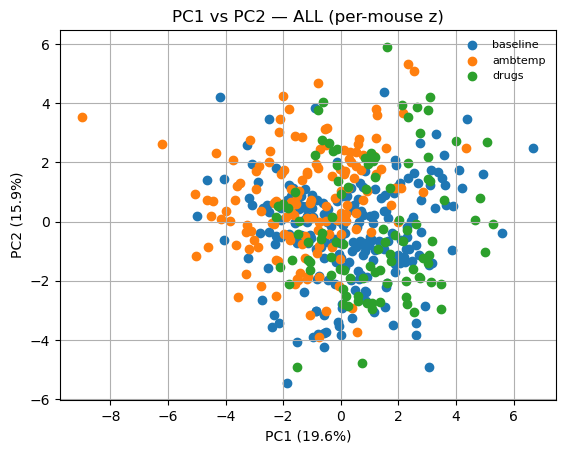

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/ALL


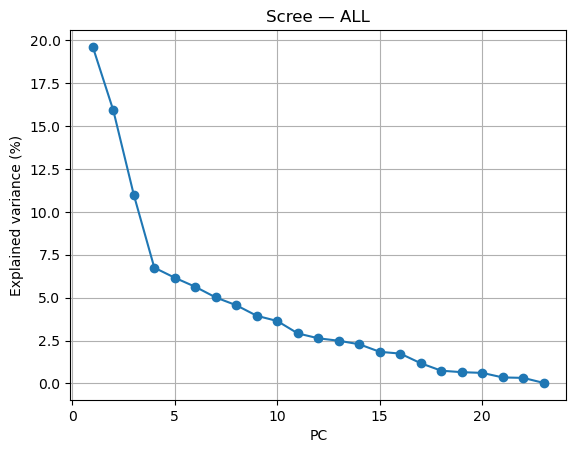

Number of PCs to reach 80% cum. explained: 10


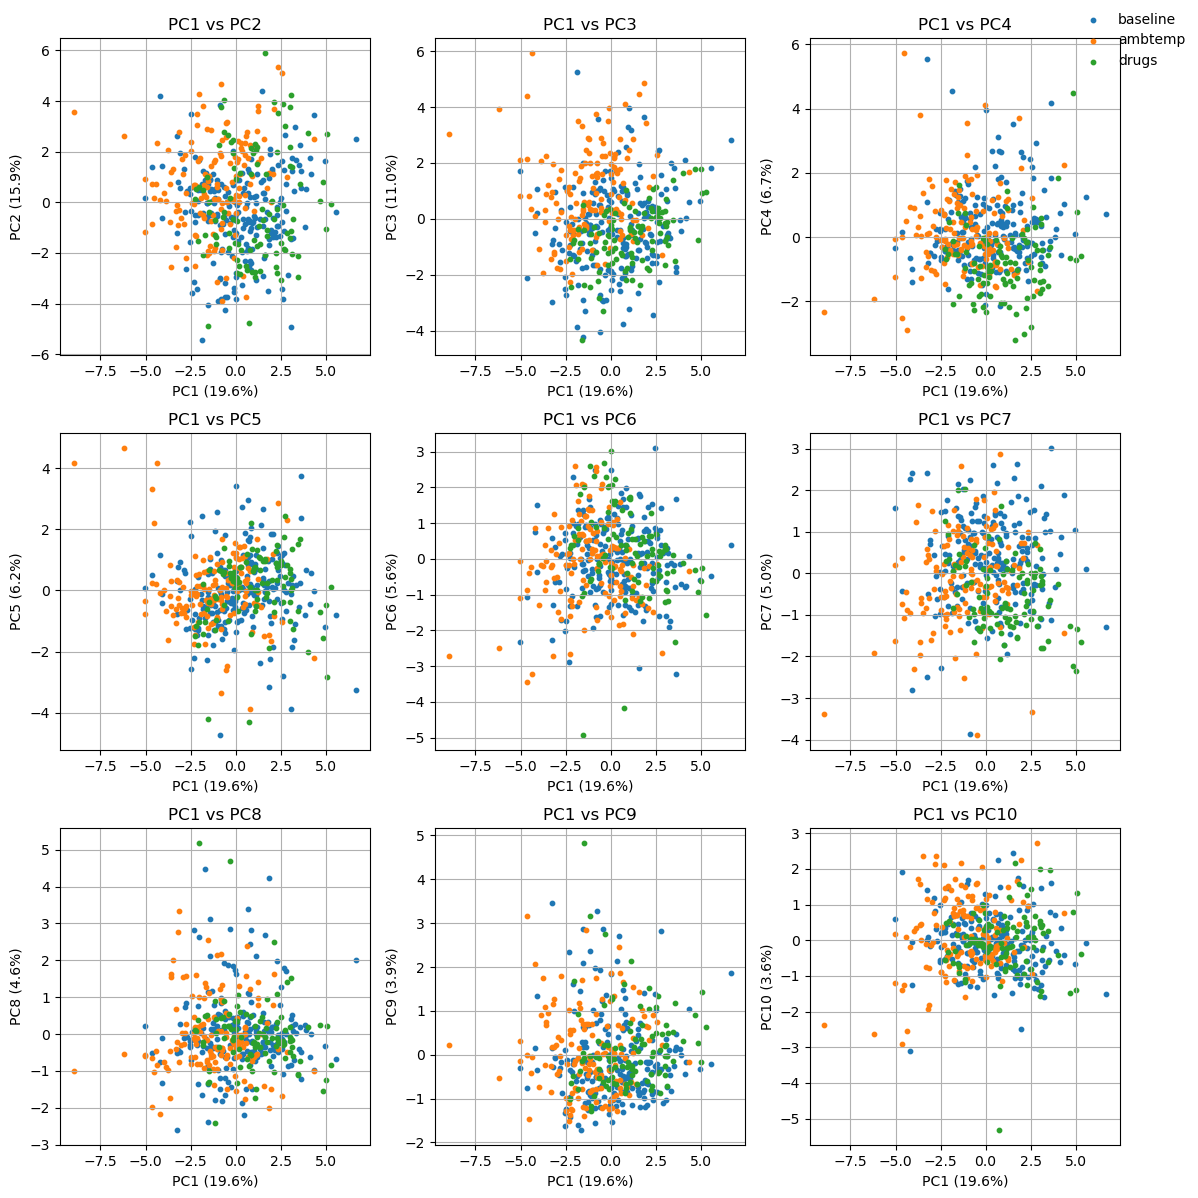

Best PC pair (by explained%): PC1, PC2  —  19.62% + 15.91% = 35.53%


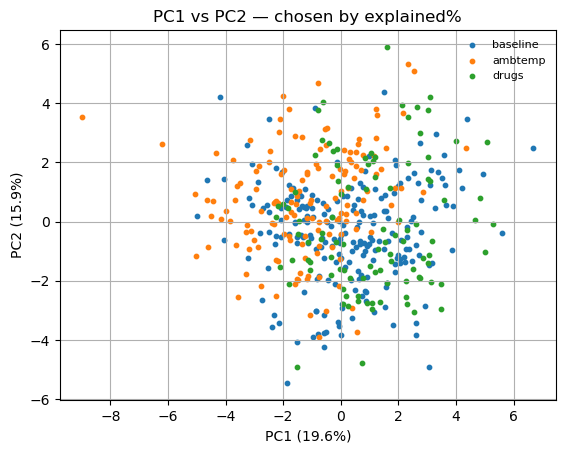

,rank,feature,loading_PC1,loading_PC2,combined_abs
0,1,theta_none,-0.181495,0.413439,0.451523
1,2,theta_peak_power_raw,-0.227055,0.379233,0.442009
2,3,peak_global_power_raw,-0.165543,0.380546,0.414994
3,4,sigma_none,0.172429,0.375579,0.413269
4,5,delta_none,0.266753,0.309720,0.408759
5,6,beta_none,0.086169,0.385900,0.395404
6,7,theta_peak_sd,0.340592,-0.012745,0.340830
7,8,hgamma_peak_power_raw,-0.323105,-0.103745,0.339352
8,9,hgamma_none,-0.330358,-0.035332,0.332242
9,10,lgamma_none,-0.278100,0.099255,0.295282


In [15]:
# Use per-mouse normalized data and skip another scaling step
X, feat_names = clean_numeric(ALL_ZM, scale=False)
if X.size == 0 or X.shape[1] < 2:
    raise ValueError("Not enough usable numeric features in ALL_ZM.")
scores, loadings, explained = run_pca_simple(X)

# (plots + save_outputs exactly as before, but using ALL_ZM for meta)
labels = ALL_ZM['condition'].astype(str).values
if pd.unique(labels).size == 1:
    labels = ALL_ZM['mouse'].astype(str).values
pc_scatter(scores, explained, labels, "PC1 vs PC2 — ALL (per-mouse z)")
save_outputs(OUT_ROOT / "ALL", "ALL", scores, loadings, explained, feat_names,
             ALL_ZM[["source_file","mouse","condition"]])

# choose threshold via scree plot
scree_plot(explained, "Scree — ALL")
n_pcs = choose_n_pcs_by_cum(explained, threshold=80.0)
print(f"Number of PCs to reach 80% cum. explained: {n_pcs}")

# plot PC1 vs PC2..PCn where n chosen by cumulative explained
labels = ALL_ZM['condition'].astype(str).values
plot_pc_pair_grid(scores, explained, labels, pcs=list(range(1, n_pcs+1)), per_row=3, figsize=(12, 4*int(np.ceil((n_pcs-1)/3))))

# pick best pair by explained variance and plot it
best_pcs = choose_best_pc_pair(explained)             # returns (i, j), 1-based
print(f"Best PC pair (by explained%): PC{best_pcs[0]}, PC{best_pcs[1]}  —  "
      f"{explained[best_pcs[0]-1]:.2f}% + {explained[best_pcs[1]-1]:.2f}% = "
      f"{explained[best_pcs[0]-1] + explained[best_pcs[1]-1]:.2f}%")

# scatter of best pair
labels_local = (ALL_ZM['condition'].astype(str).values if 'ALL_ZM' in globals() else ALL['condition'].astype(str).values) \
               if 'ALL' in globals() and 'ALL_ZM' in globals() else labels
# adjust labels variable name depending on context (ALL / per-mouse / per-condition)
pc_scatter_pair(scores, explained, labels, pcs=best_pcs,
                title=f"PC{best_pcs[0]} vs PC{best_pcs[1]} — chosen by explained%")

# list + save top contributing features for that pair
tbl_pair = save_pair_top_features(OUT_ROOT / "ALL", "ALL", loadings, feat_names, pcs=best_pcs, k=20)
display(tbl_pair.head(20))


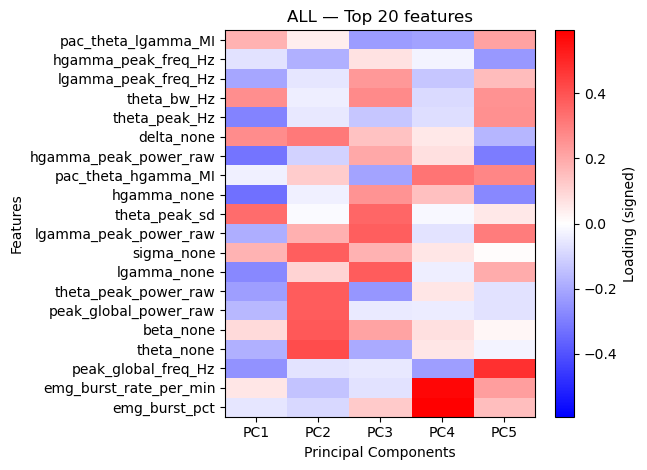

In [6]:
# Heatmap for ALL (top 20 features, PCs 1–5; tweak as needed)
plot_pc_feature_heatmap(
    loadings=loadings,
    feat_names=feat_names,
    title="ALL",
    out_path=OUT_ROOT / "ALL" / "pc_feature_heatmap.png",
    top_n=20,
    pcs=list(range(1, min(6, loadings.shape[1]+1)))
)


,PC,feature,loading,abs_loading,rank
0,1,theta_peak_sd,0.340592,0.340592,1
1,1,hgamma_none,-0.330358,0.330358,2
2,1,hgamma_peak_power_raw,-0.323105,0.323105,3
3,1,theta_peak_Hz,-0.286406,0.286406,4
4,1,lgamma_none,-0.278100,0.278100,5
5,1,delta_none,0.266753,0.266753,6
6,1,theta_bw_Hz,0.262528,0.262528,7
7,1,peak_global_freq_Hz,-0.250938,0.250938,8
8,1,theta_peak_power_raw,-0.227055,0.227055,9
9,1,lgamma_peak_freq_Hz,-0.205767,0.205767,10


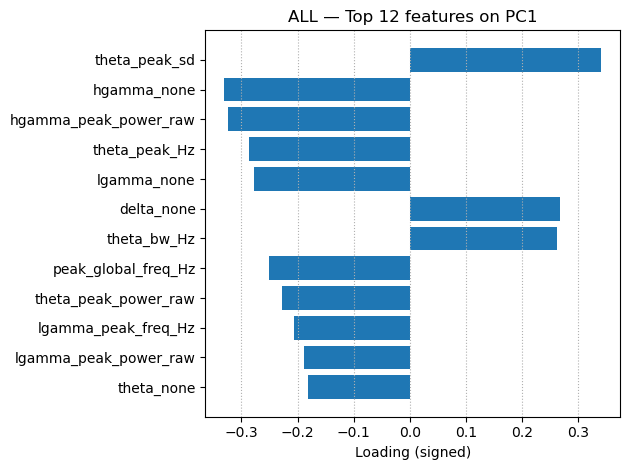

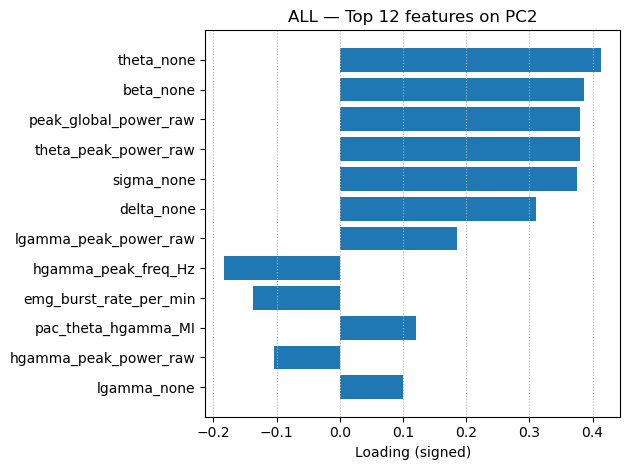

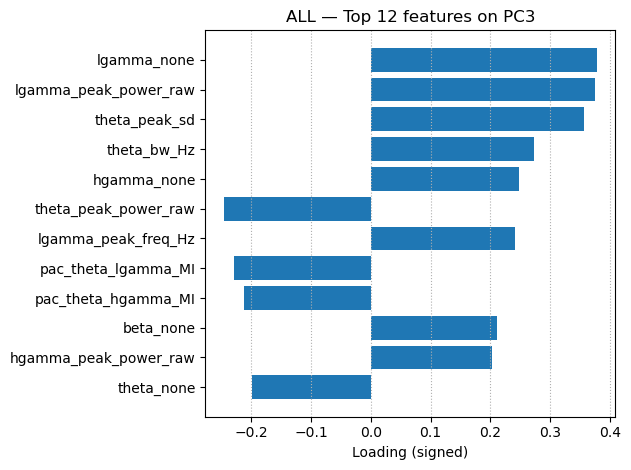

In [7]:
# List + save top loadings for ALL
tbl_all = save_top_loadings_csv(OUT_ROOT / "ALL", "ALL", loadings, feat_names, k=12)
display(tbl_all.head(24))  # first two PCs’ top features

# Bar plots for PC1–PC3 (change range as you like)
for pc in range(1, min(4, loadings.shape[1]+1)):
    plot_top_loadings_bar(loadings, feat_names, pc=pc, k=12, title_prefix="ALL —")


SEPARATION

[ALL] Best PC pair by separation: PC4 vs PC7
   Silhouette=0.007  Calinski=27.8  DBI=4.741  LDA CV=0.5462365591397849


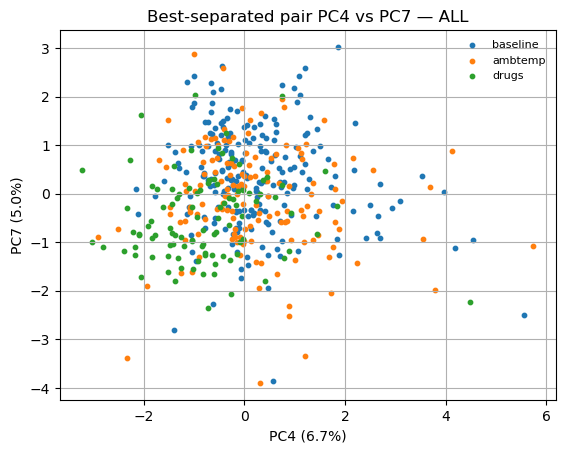

,rank,feature,loading_PC4,loading_PC7,combined_abs
0,1,emg_burst_pct,0.594051,-0.106942,0.603600
1,2,emg_burst_rate_per_min,0.578791,0.021447,0.579188
2,3,beta_none,0.070437,0.398039,0.404223
3,4,sigma_none,0.058184,0.380982,0.385399
4,5,pac_theta_hgamma_MI,0.323487,0.110997,0.342000
5,6,lgamma_peak_freq_Hz,-0.130700,-0.314986,0.341026
6,7,hgamma_peak_freq_Hz,-0.024585,0.328512,0.329430
7,8,peak_global_freq_Hz,-0.225521,0.228346,0.320939
8,9,theta_peak_Hz,-0.078175,0.308852,0.318592
9,10,peak_global_power_raw,-0.046291,-0.260808,0.264884


In [14]:

# labels for separation test (prefers condition; fallback to mouse)
labels_all = ALL_ZM['condition'].astype(str).values if 'ALL_ZM' in globals() else ALL['condition'].astype(str).values
if pd.unique(labels_all).size == 1:
    labels_all = (ALL_ZM if 'ALL_ZM' in globals() else ALL)['mouse'].astype(str).values

best_pcs, best_metrics, all_pairs = choose_best_pc_pair_by_separation(
    scores, labels_all, explained=explained, max_pc=min(10, scores.shape[1]), tie_break="variance"
)
print(f"[ALL] Best PC pair by separation: PC{best_pcs[0]} vs PC{best_pcs[1]}")
print(f"   Silhouette={best_metrics['silhouette']:.3f}  Calinski={best_metrics['calinski']:.1f}  "
      f"DBI={best_metrics['dbi']:.3f}  LDA CV={best_metrics['lda_cv'] if not np.isnan(best_metrics['lda_cv']) else 'n/a'}")

# Plot that pair and save top features for the pair
pc_scatter_pair(scores, explained, labels_all, pcs=best_pcs,
                title=f"Best-separated pair PC{best_pcs[0]} vs PC{best_pcs[1]} — ALL")

tbl_pair = save_pair_top_features(OUT_ROOT / "ALL", "ALL", loadings, feat_names, pcs=best_pcs, k=20)
display(tbl_pair.head(20))

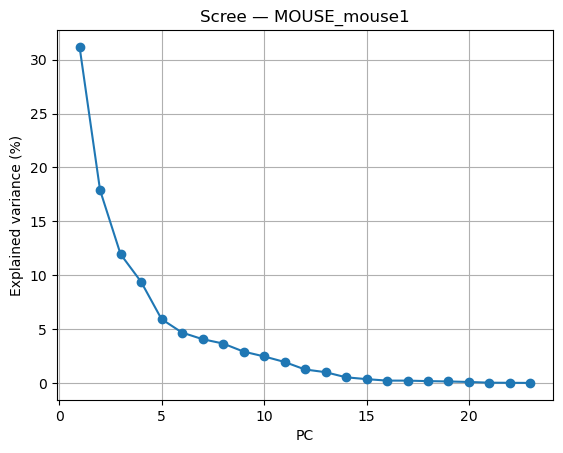

Number of PCs to reach 80% cum. explained (mouse mouse1): 6


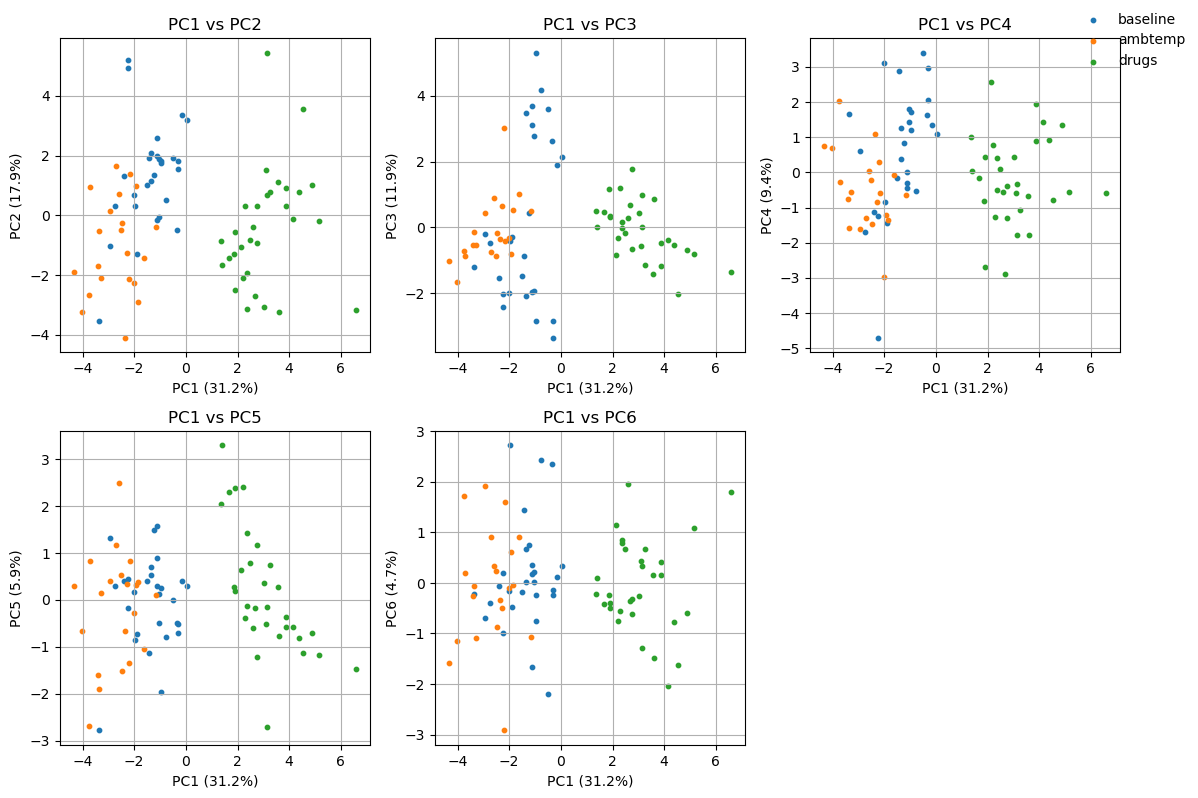

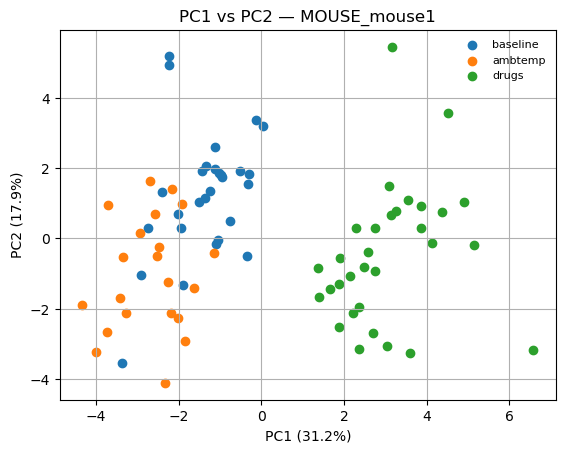

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse1


,PC,feature,loading,abs_loading,rank
0,1,delta_none,0.334524,0.334524,1
1,1,hgamma_peak_freq_Hz,-0.305582,0.305582,2
2,1,hgamma_none,-0.305479,0.305479,3
3,1,sigma_none,0.304603,0.304603,4
4,1,hgamma_peak_power_raw,-0.286336,0.286336,5
5,1,theta_none,0.279879,0.279879,6
6,1,beta_none,0.279815,0.279815,7
7,1,peak_global_power_raw,0.244681,0.244681,8
8,1,theta_peak_power_raw,0.240388,0.240388,9
9,1,pac_theta_lgamma_MI,0.228162,0.228162,10


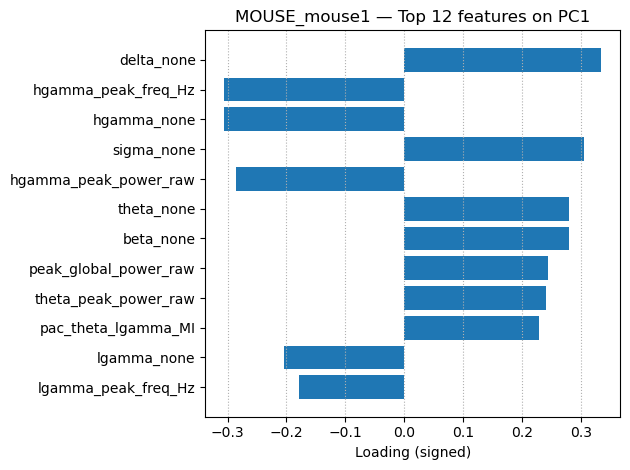

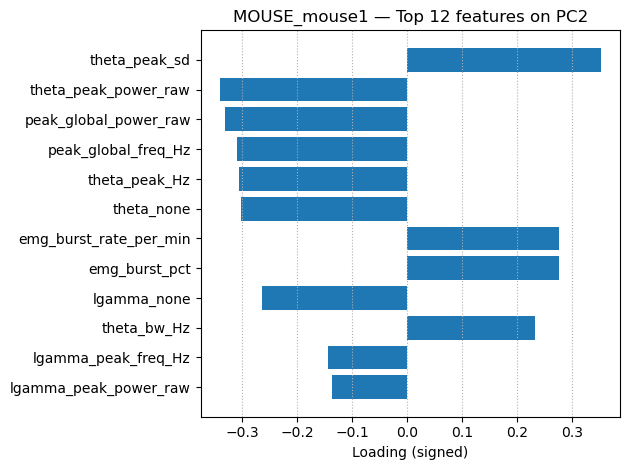

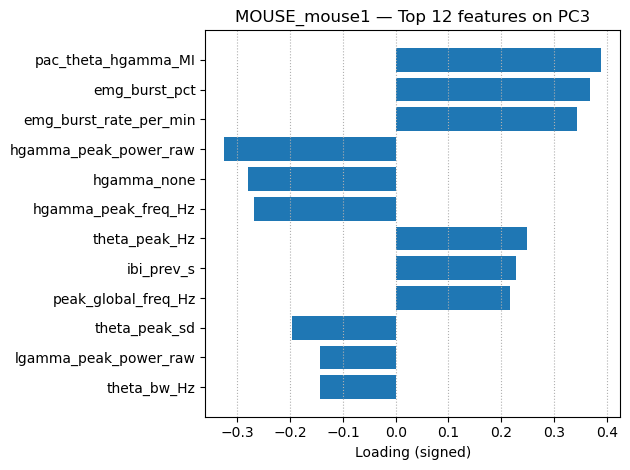

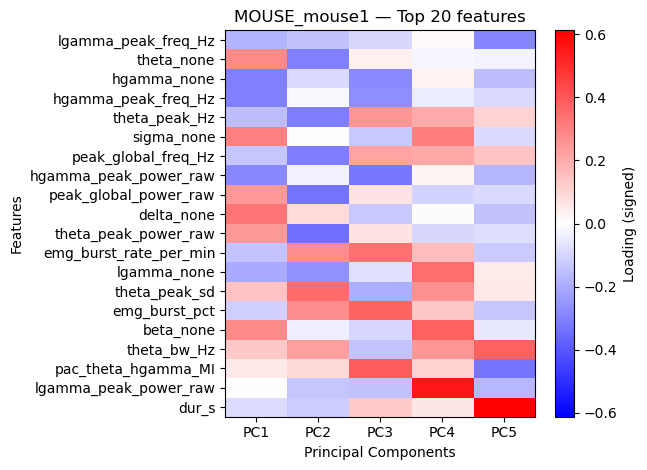

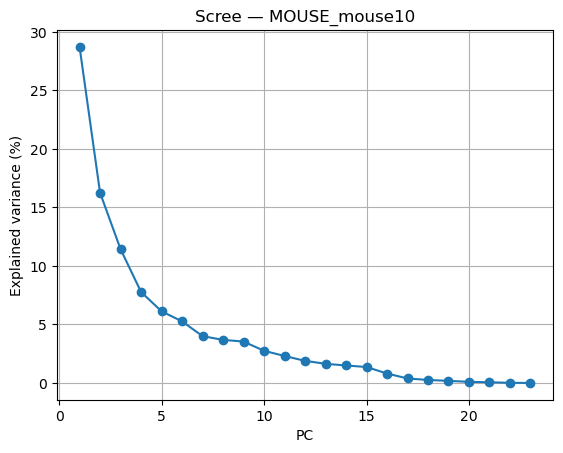

Number of PCs to reach 80% cum. explained (mouse mouse10): 8


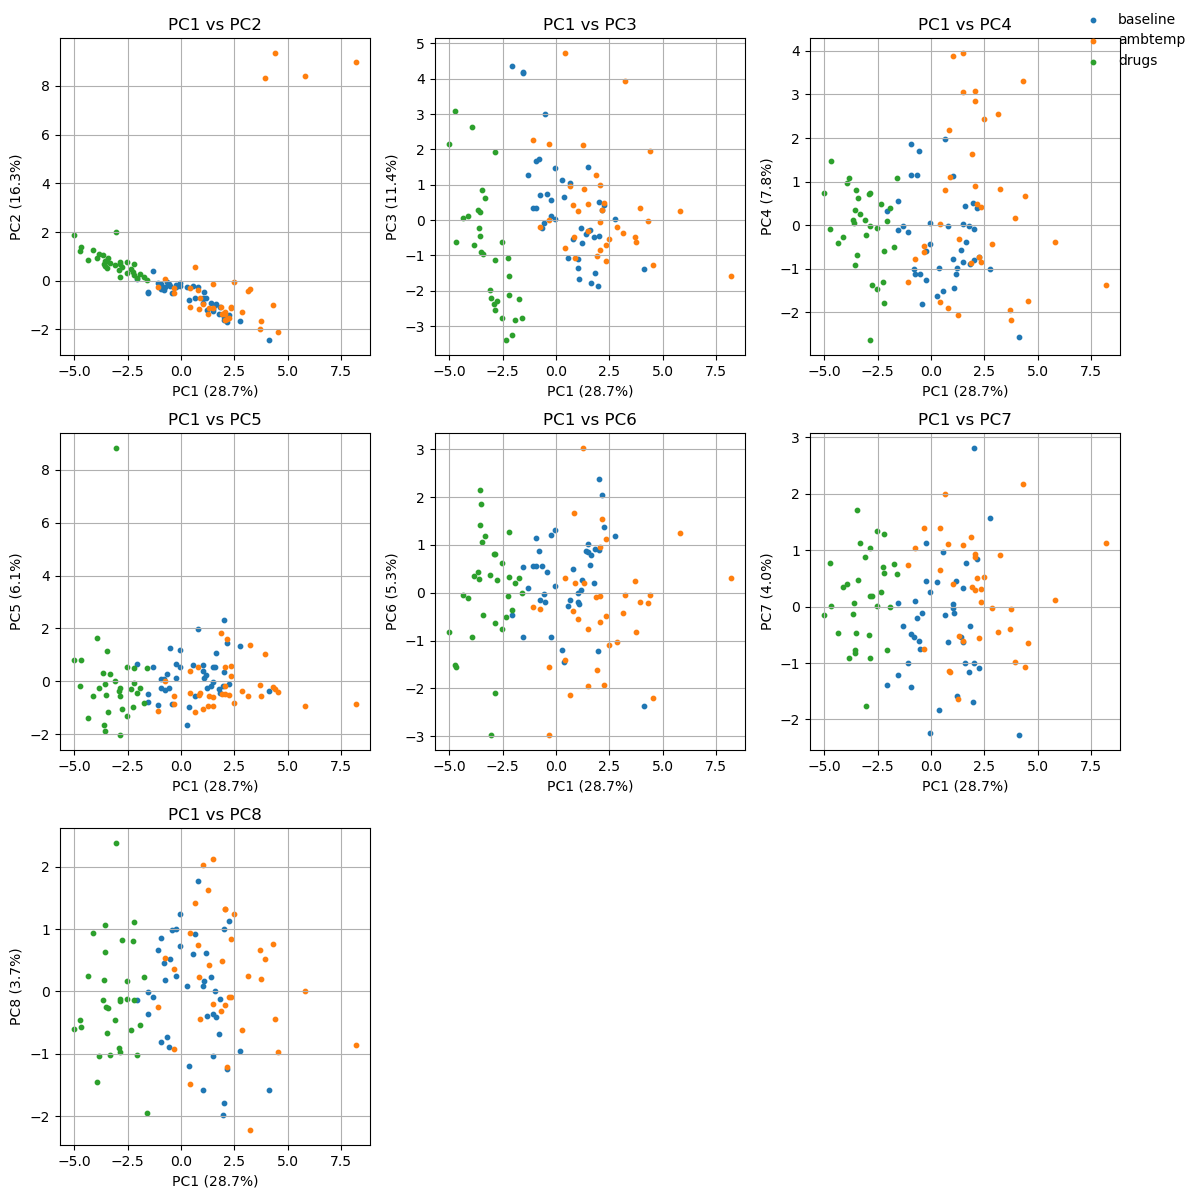

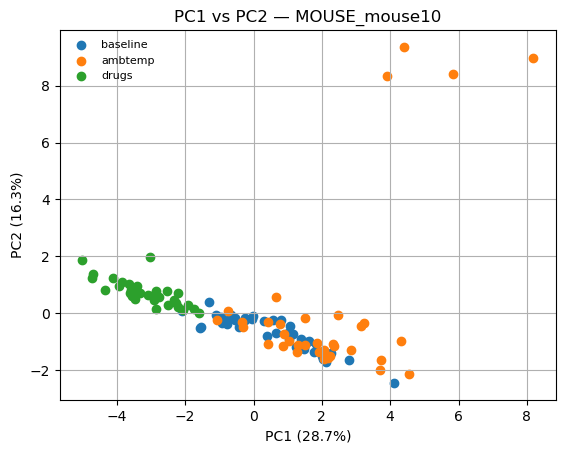

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse10


,PC,feature,loading,abs_loading,rank
0,1,hgamma_peak_power_raw,0.346396,0.346396,1
1,1,hgamma_none,0.342211,0.342211,2
2,1,theta_peak_power_raw,0.338728,0.338728,3
3,1,theta_none,0.334811,0.334811,4
4,1,peak_global_power_raw,0.288582,0.288582,5
5,1,theta_peak_sd,-0.279078,0.279078,6
6,1,beta_none,0.239629,0.239629,7
7,1,lgamma_none,0.191239,0.191239,8
8,1,theta_bw_Hz,-0.188889,0.188889,9
9,1,theta_peak_Hz,0.188075,0.188075,10


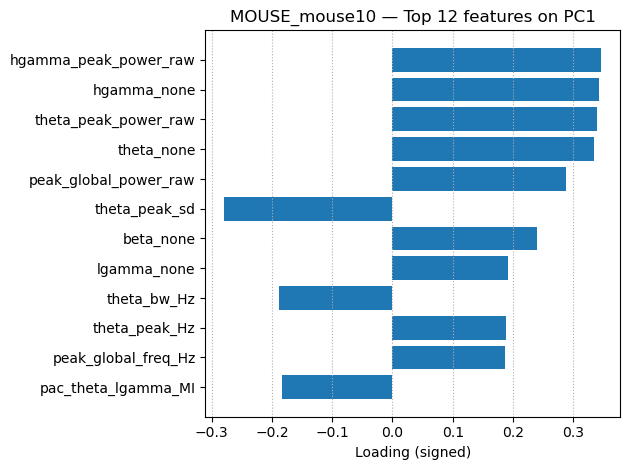

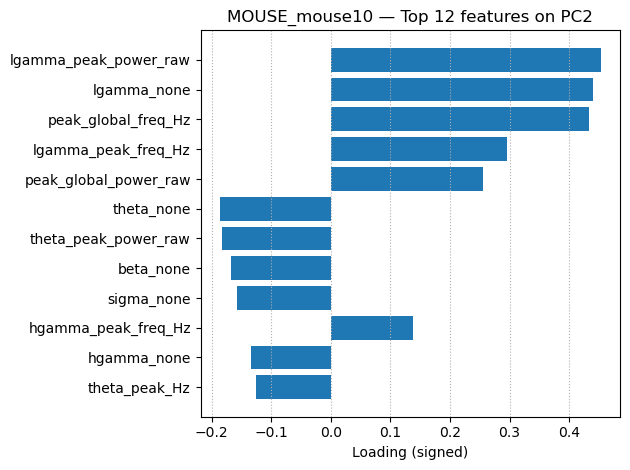

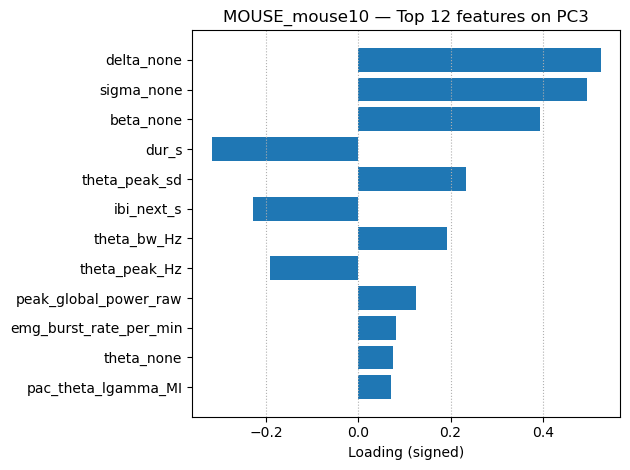

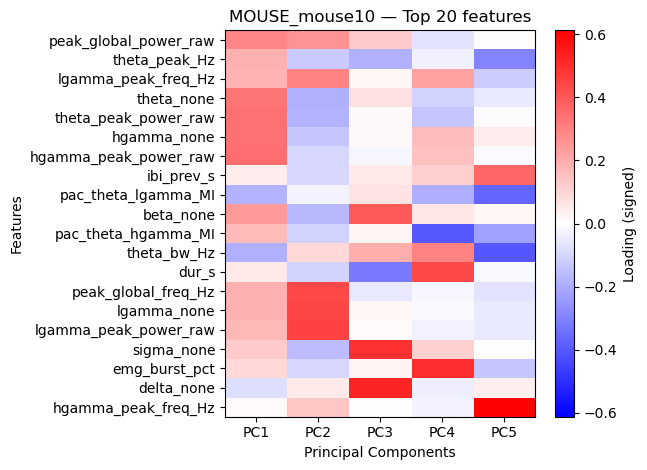

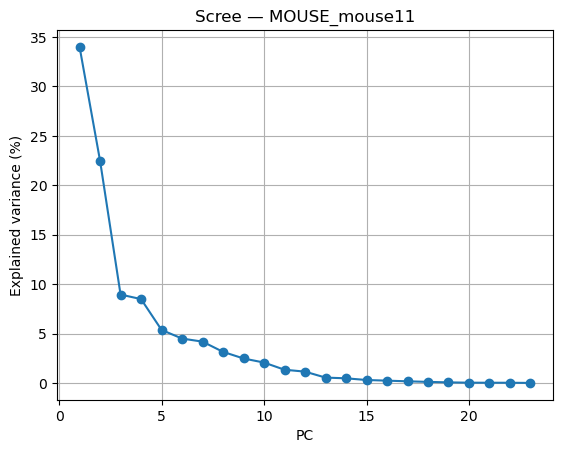

Number of PCs to reach 80% cum. explained (mouse mouse11): 6


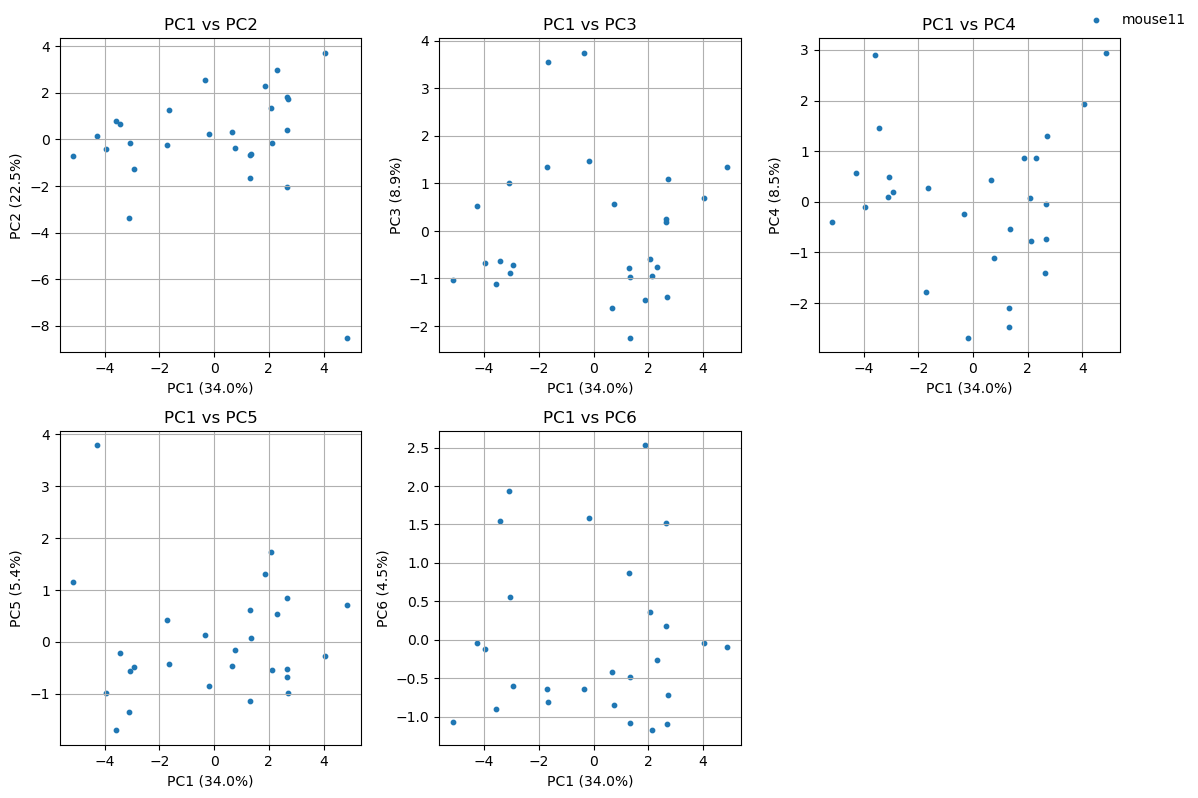

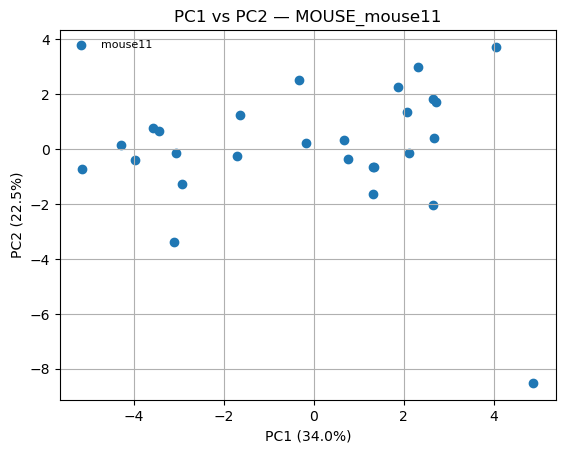

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse11


,PC,feature,loading,abs_loading,rank
0,1,hgamma_peak_power_raw,0.337480,0.337480,1
1,1,delta_none,-0.331701,0.331701,2
2,1,peak_global_freq_Hz,0.317019,0.317019,3
3,1,hgamma_none,0.310017,0.310017,4
4,1,theta_peak_Hz,0.308916,0.308916,5
5,1,lgamma_peak_freq_Hz,0.294830,0.294830,6
6,1,sigma_none,-0.291952,0.291952,7
7,1,lgamma_none,0.284597,0.284597,8
8,1,beta_none,-0.282737,0.282737,9
9,1,theta_peak_sd,-0.212251,0.212251,10


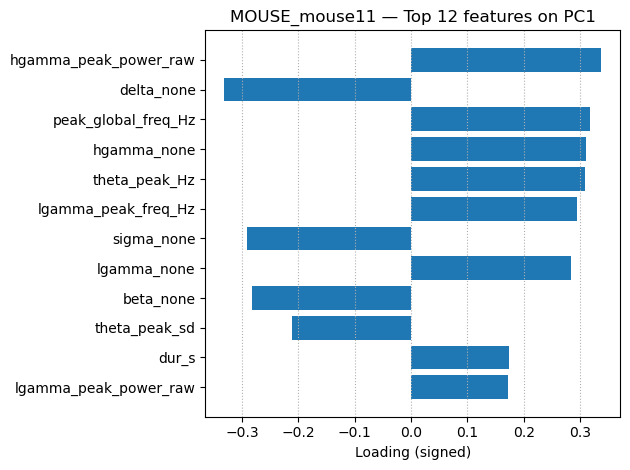

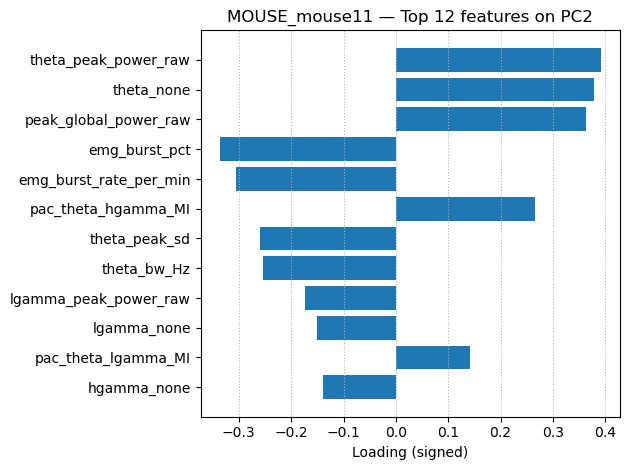

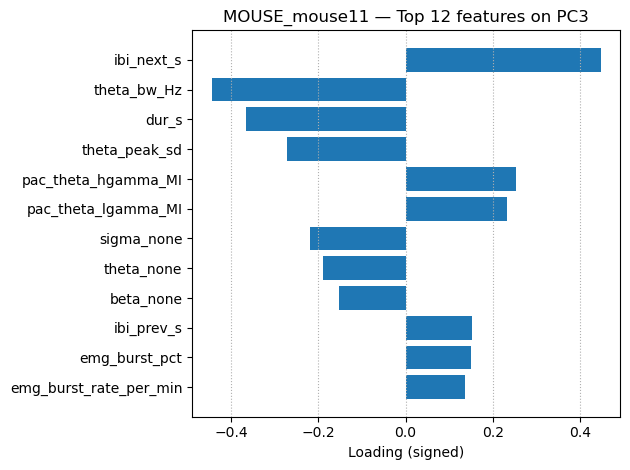

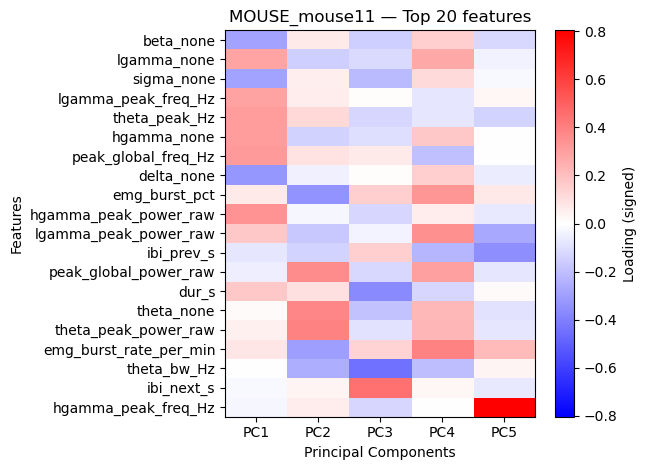

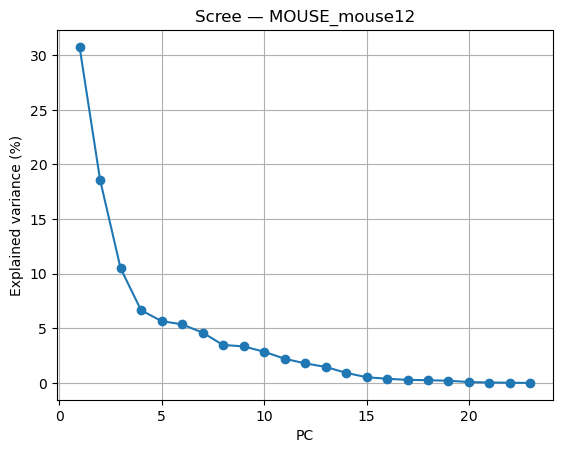

Number of PCs to reach 80% cum. explained (mouse mouse12): 7


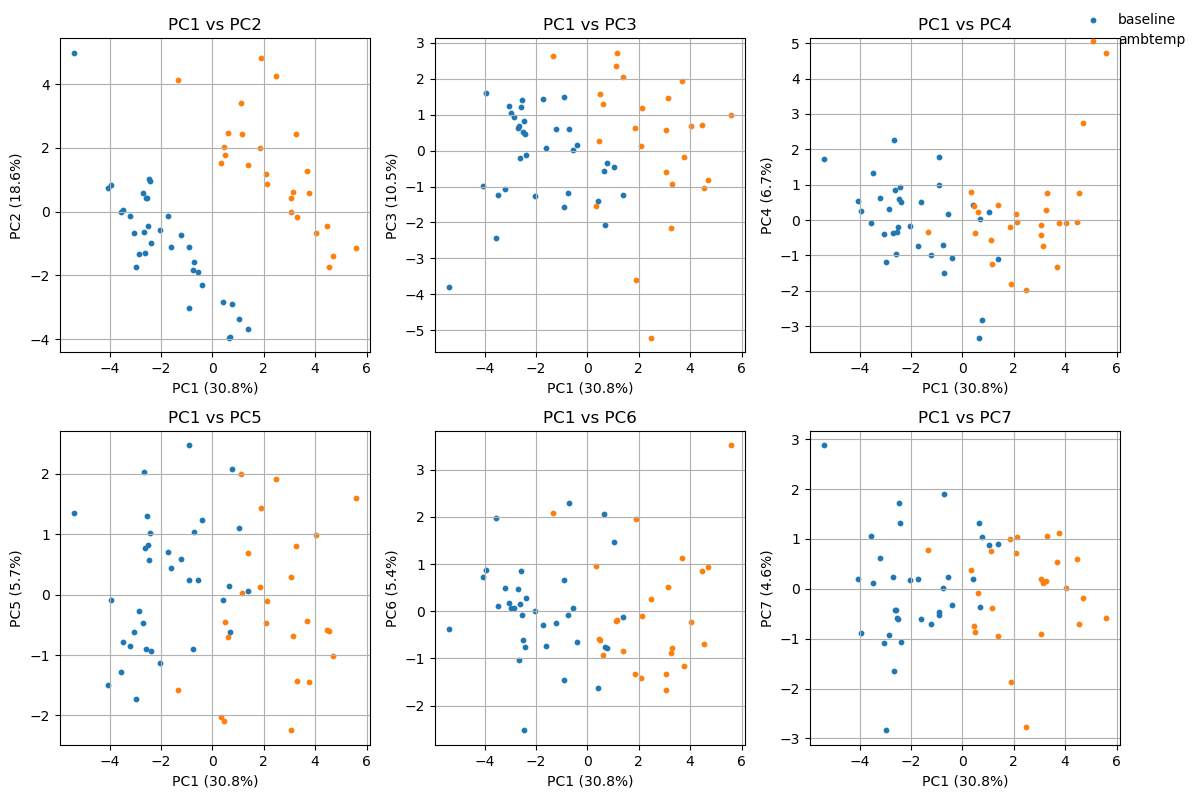

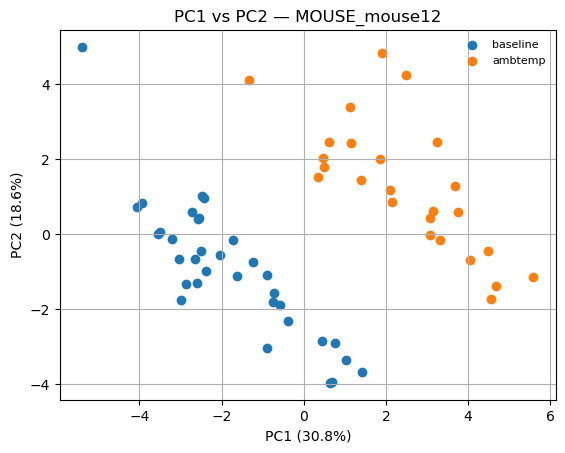

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse12


,PC,feature,loading,abs_loading,rank
0,1,hgamma_peak_power_raw,0.319777,0.319777,1
1,1,hgamma_none,0.317640,0.317640,2
2,1,lgamma_none,0.310858,0.310858,3
3,1,lgamma_peak_power_raw,0.309876,0.309876,4
4,1,lgamma_peak_freq_Hz,0.297300,0.297300,5
5,1,theta_peak_power_raw,0.253427,0.253427,6
6,1,theta_peak_sd,-0.243963,0.243963,7
7,1,sigma_none,-0.239662,0.239662,8
8,1,theta_none,0.239113,0.239113,9
9,1,pac_theta_lgamma_MI,-0.225923,0.225923,10


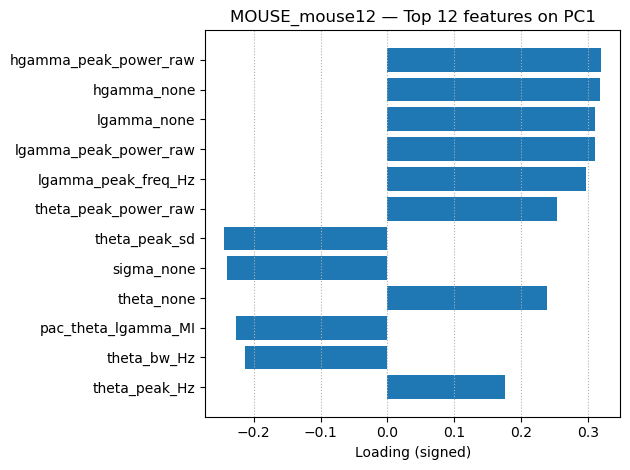

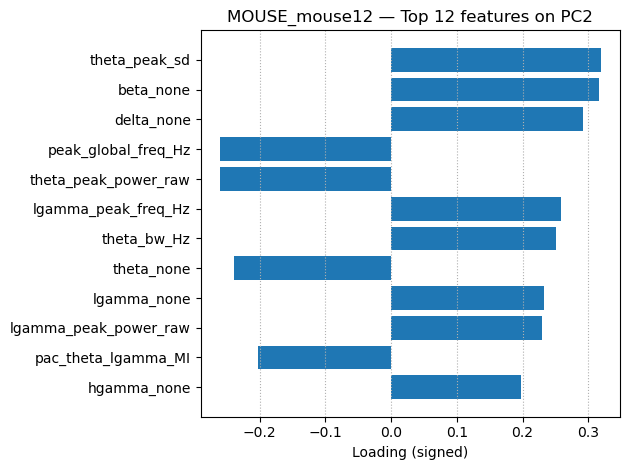

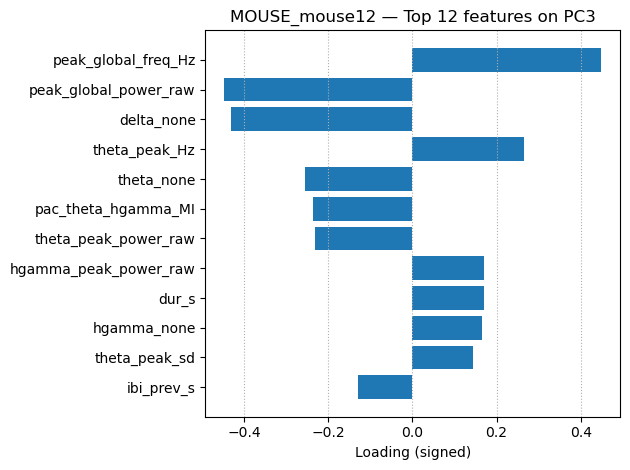

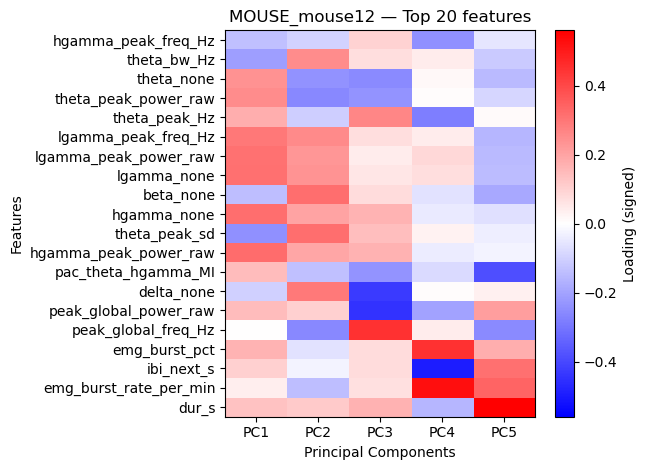

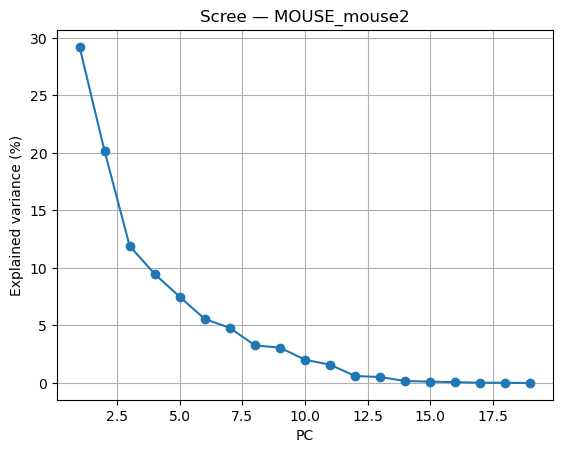

Number of PCs to reach 80% cum. explained (mouse mouse2): 6


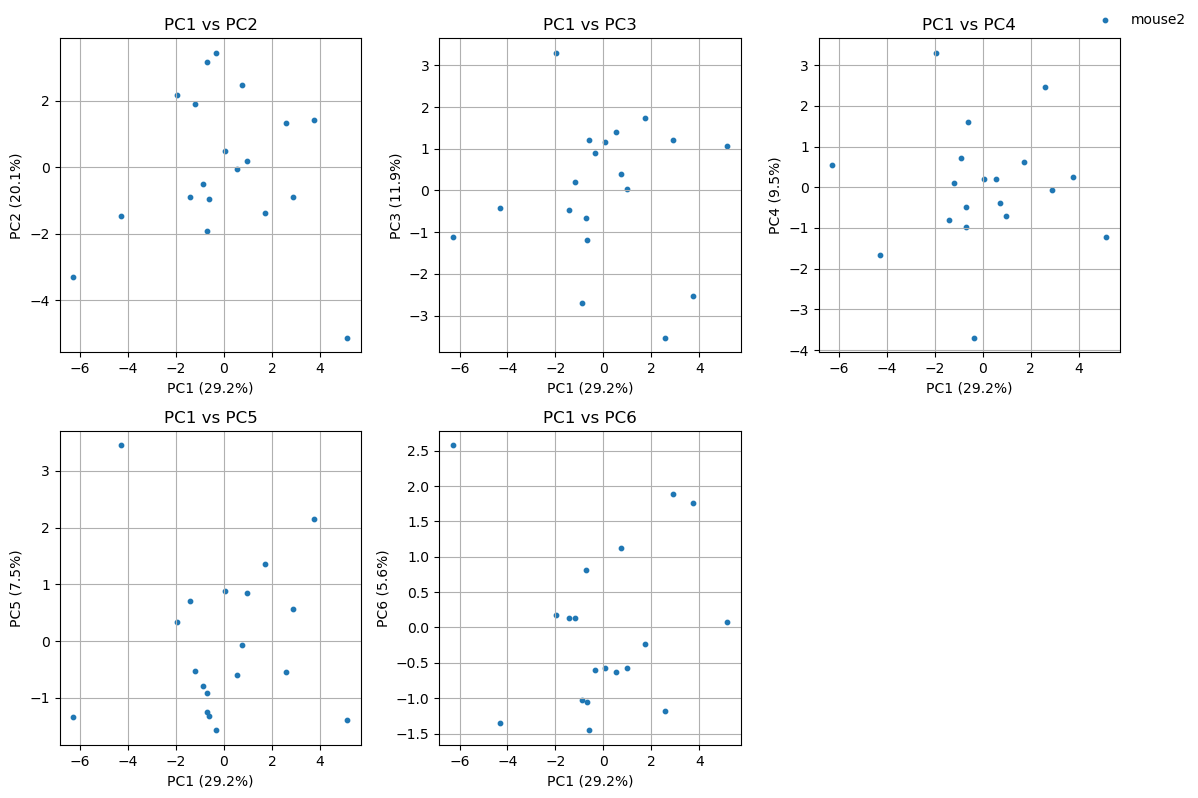

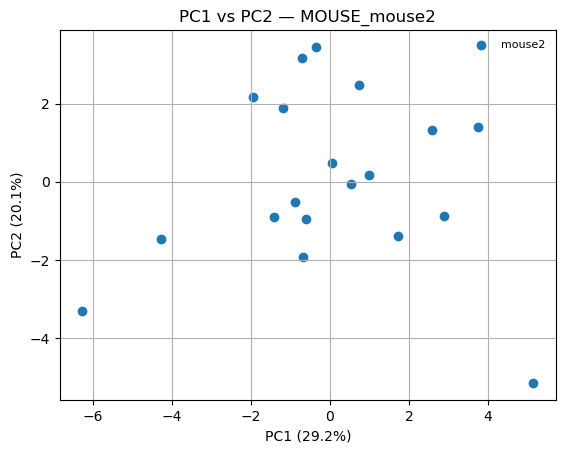

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse2


,PC,feature,loading,abs_loading,rank
0,1,lgamma_none,0.337743,0.337743,1
1,1,theta_bw_Hz,-0.299136,0.299136,2
2,1,emg_burst_rate_per_min,-0.286823,0.286823,3
3,1,emg_burst_pct,-0.282694,0.282694,4
4,1,delta_none,-0.257665,0.257665,5
5,1,theta_peak_sd,-0.256562,0.256562,6
6,1,theta_peak_power_raw,0.255879,0.255879,7
7,1,peak_global_power_raw,0.255879,0.255879,8
8,1,pac_theta_hgamma_MI,-0.246593,0.246593,9
9,1,hgamma_none,0.237600,0.237600,10


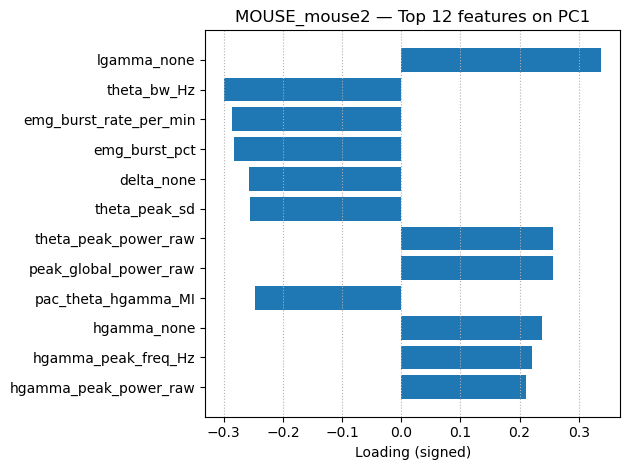

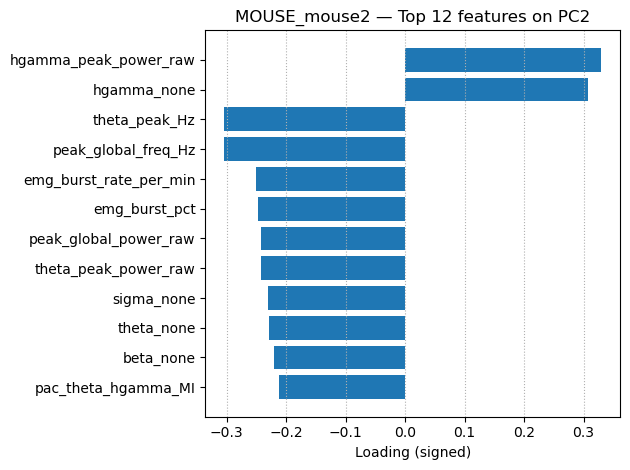

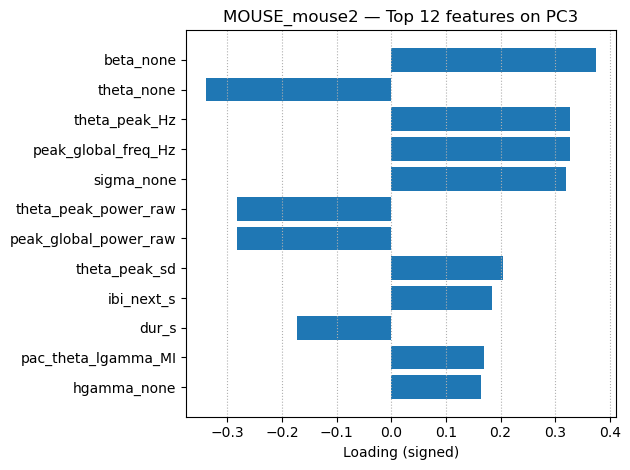

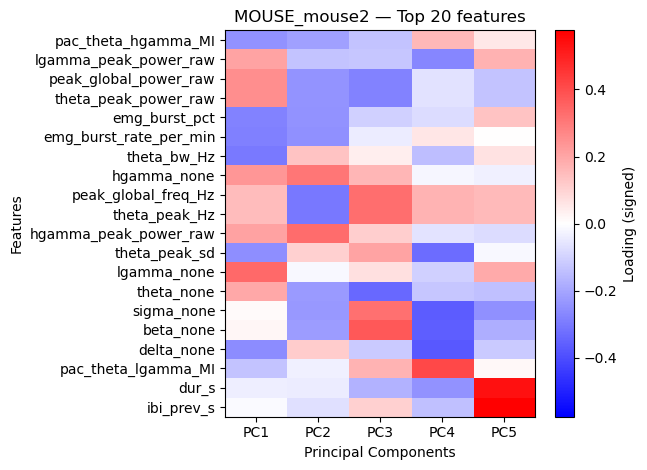

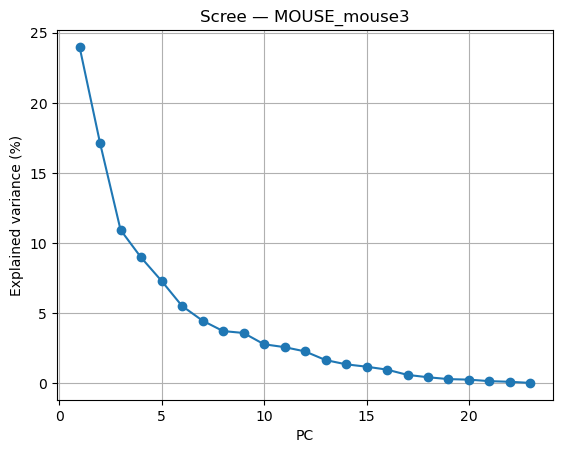

Number of PCs to reach 80% cum. explained (mouse mouse3): 8


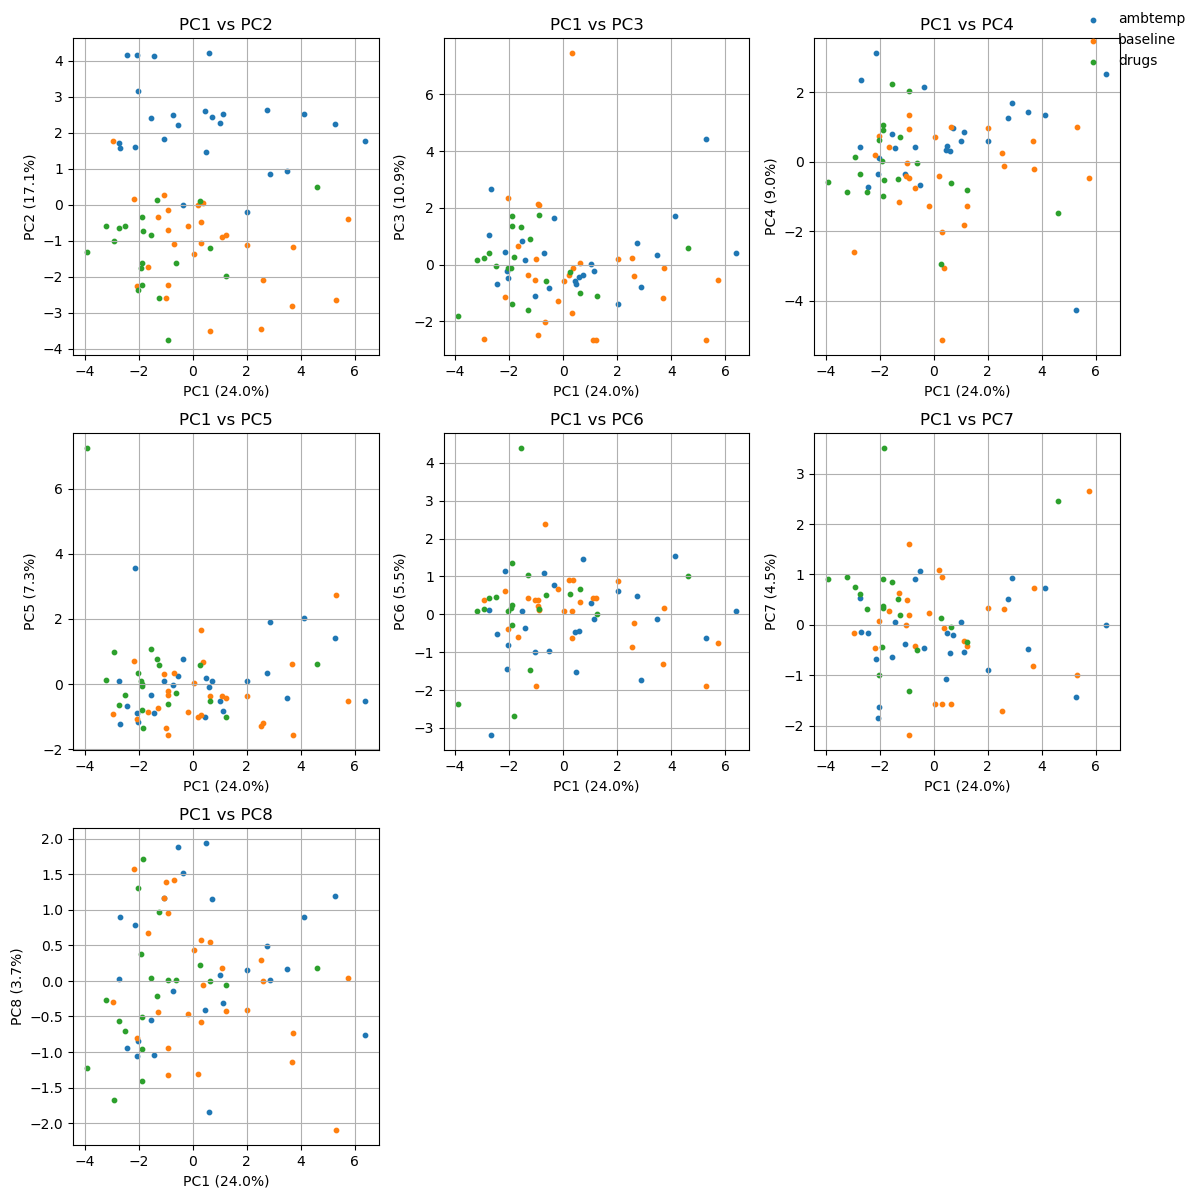

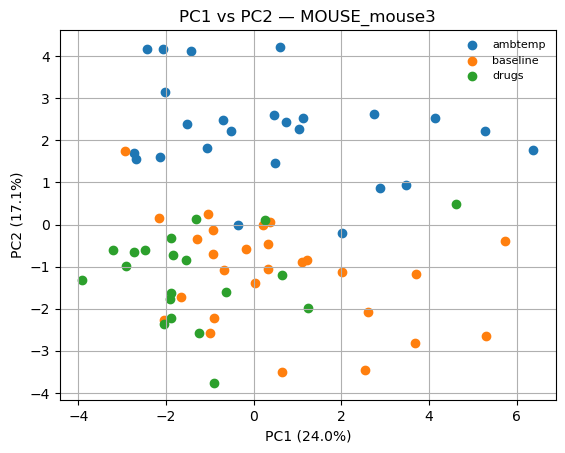

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse3


,PC,feature,loading,abs_loading,rank
0,1,sigma_none,0.385488,0.385488,1
1,1,beta_none,0.320914,0.320914,2
2,1,hgamma_peak_power_raw,-0.318929,0.318929,3
3,1,hgamma_none,-0.310553,0.310553,4
4,1,delta_none,0.288580,0.288580,5
5,1,theta_peak_Hz,-0.273500,0.273500,6
6,1,theta_peak_sd,0.261751,0.261751,7
7,1,pac_theta_hgamma_MI,0.256337,0.256337,8
8,1,theta_bw_Hz,0.219613,0.219613,9
9,1,pac_theta_lgamma_MI,0.218838,0.218838,10


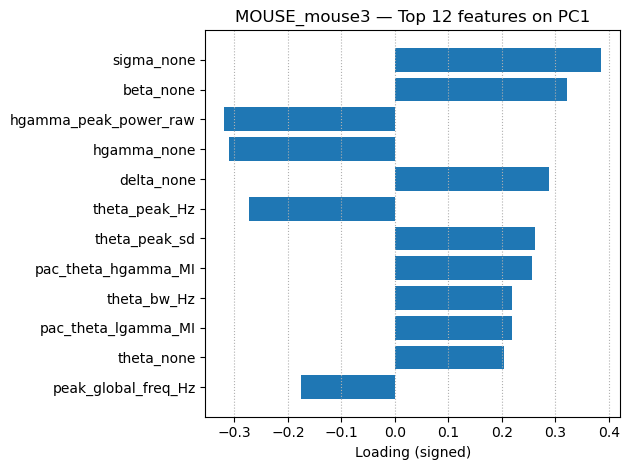

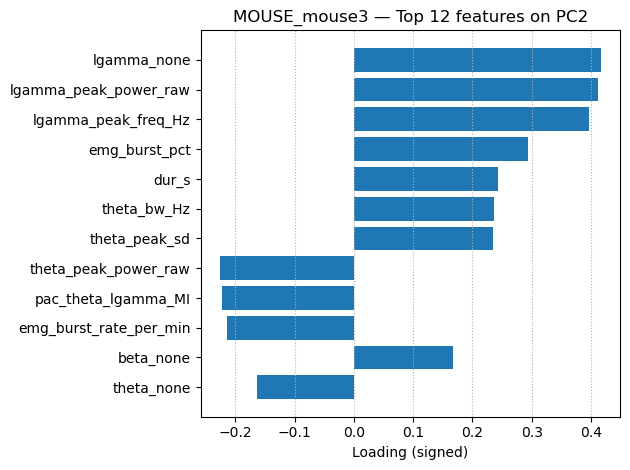

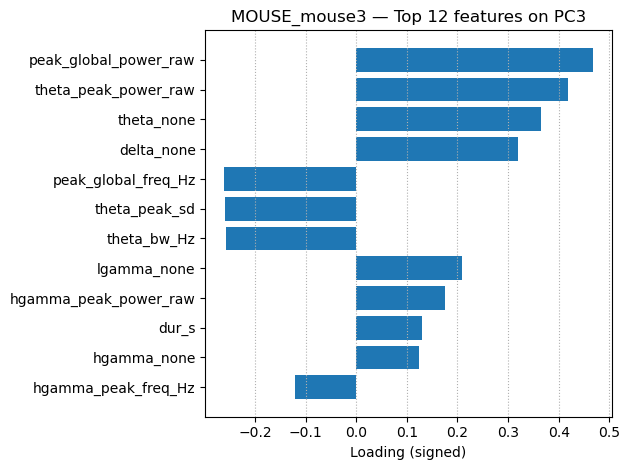

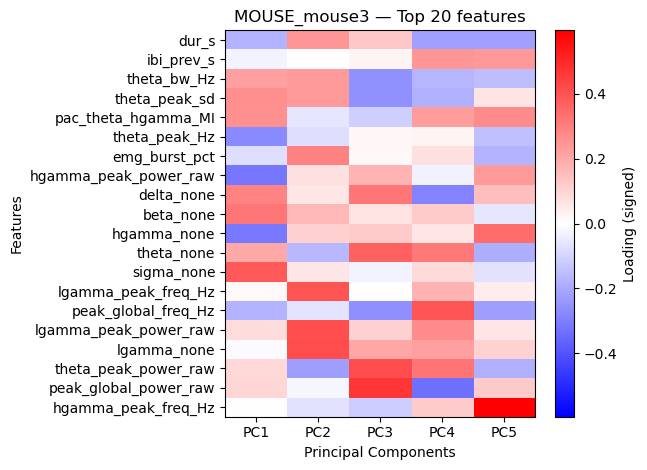

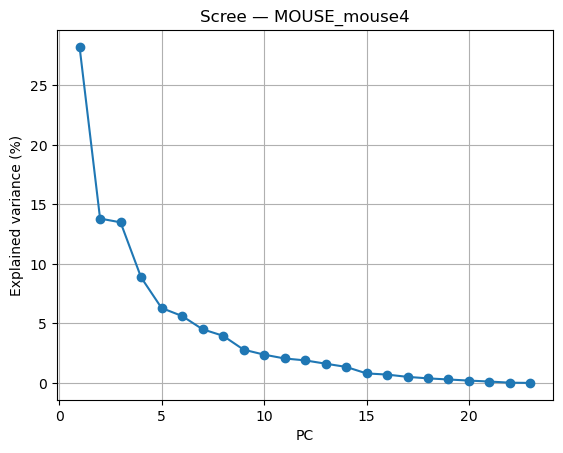

Number of PCs to reach 80% cum. explained (mouse mouse4): 7


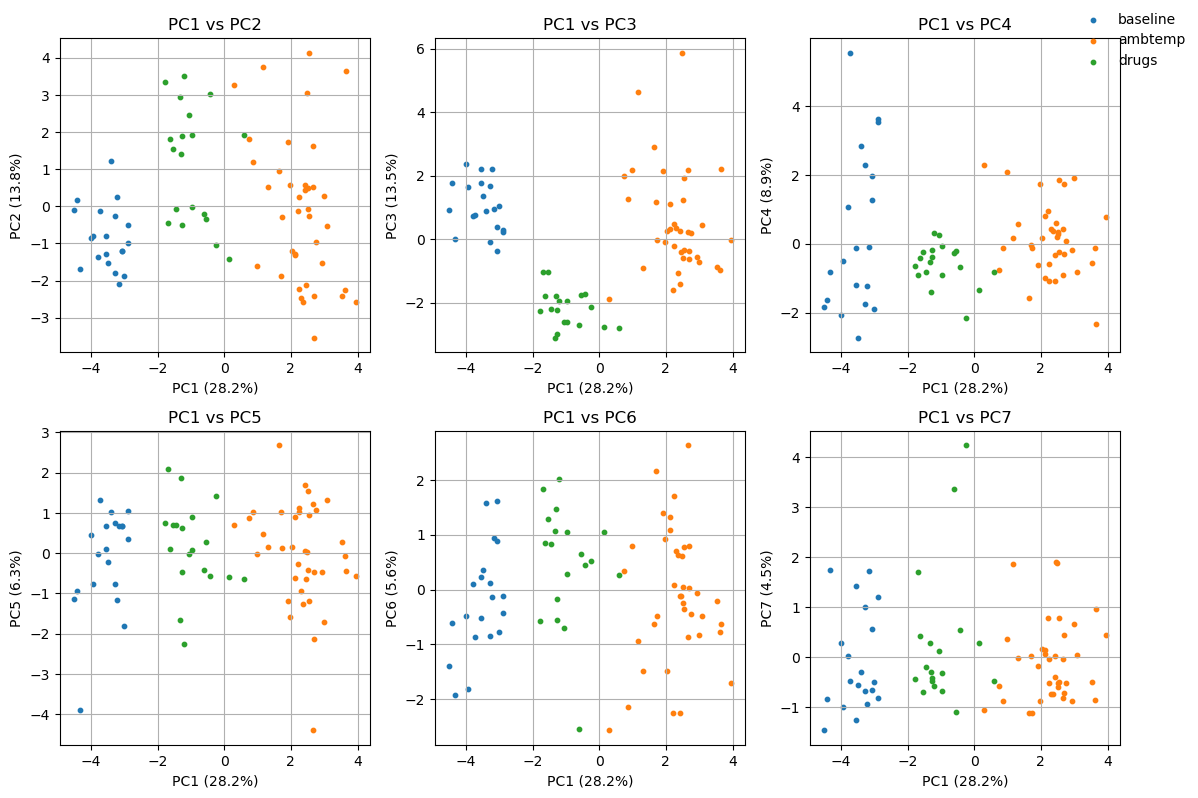

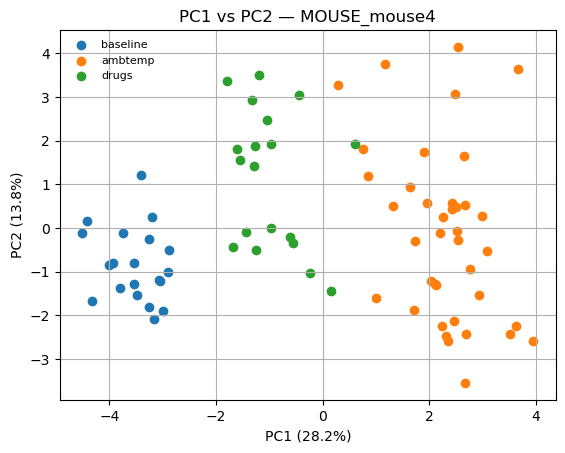

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse4


,PC,feature,loading,abs_loading,rank
0,1,beta_none,0.355310,0.355310,1
1,1,sigma_none,0.348899,0.348899,2
2,1,theta_none,0.332127,0.332127,3
3,1,peak_global_power_raw,0.327275,0.327275,4
4,1,theta_peak_power_raw,0.319228,0.319228,5
5,1,lgamma_peak_power_raw,0.303617,0.303617,6
6,1,delta_none,0.279461,0.279461,7
7,1,lgamma_none,0.267725,0.267725,8
8,1,hgamma_peak_freq_Hz,-0.220442,0.220442,9
9,1,lgamma_peak_freq_Hz,-0.195268,0.195268,10


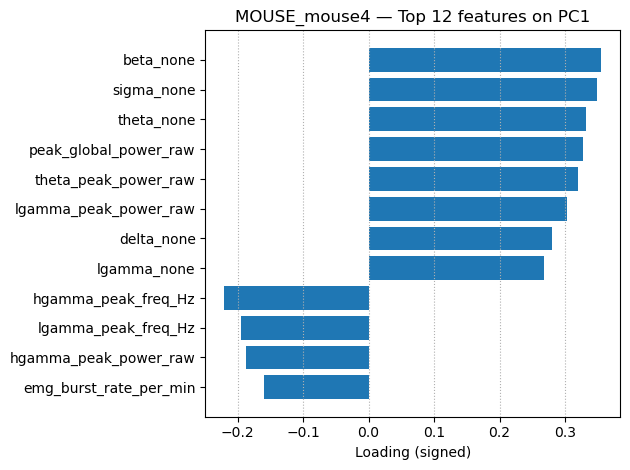

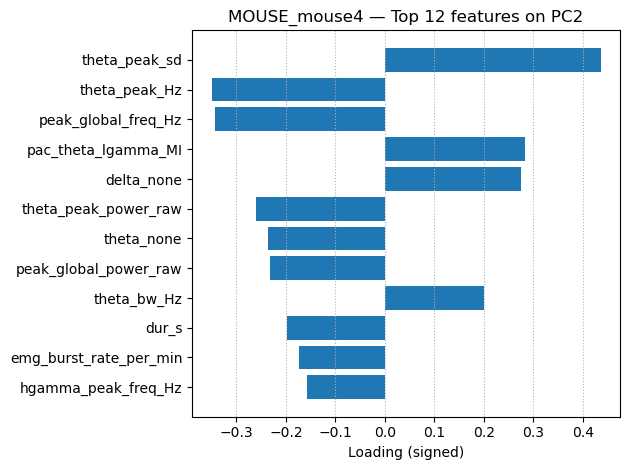

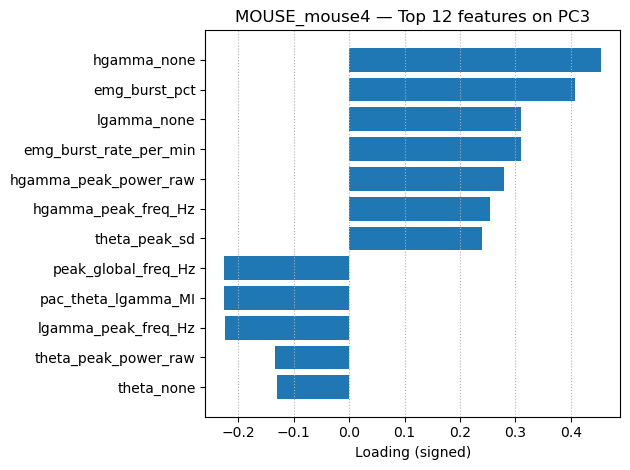

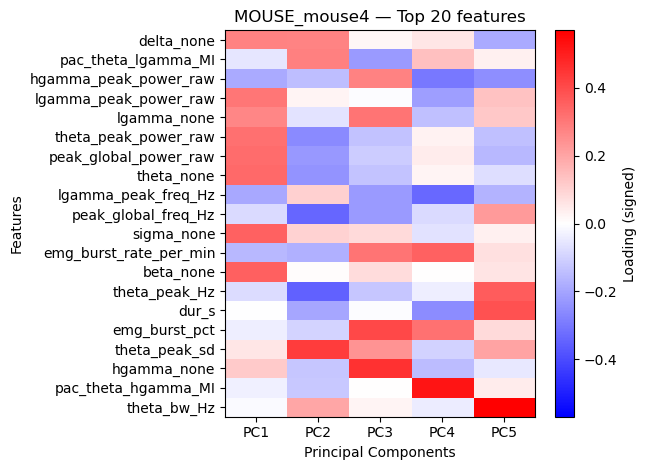

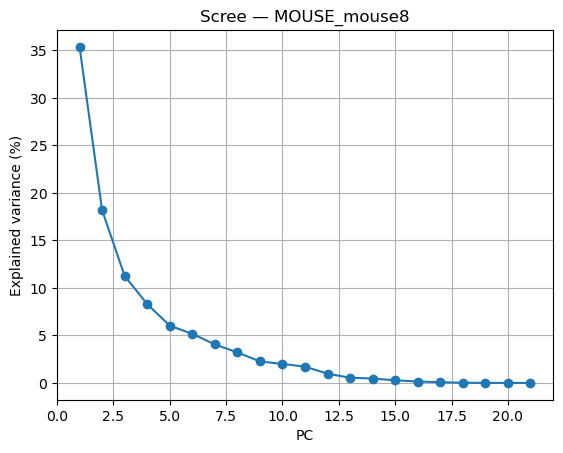

Number of PCs to reach 80% cum. explained (mouse mouse8): 6


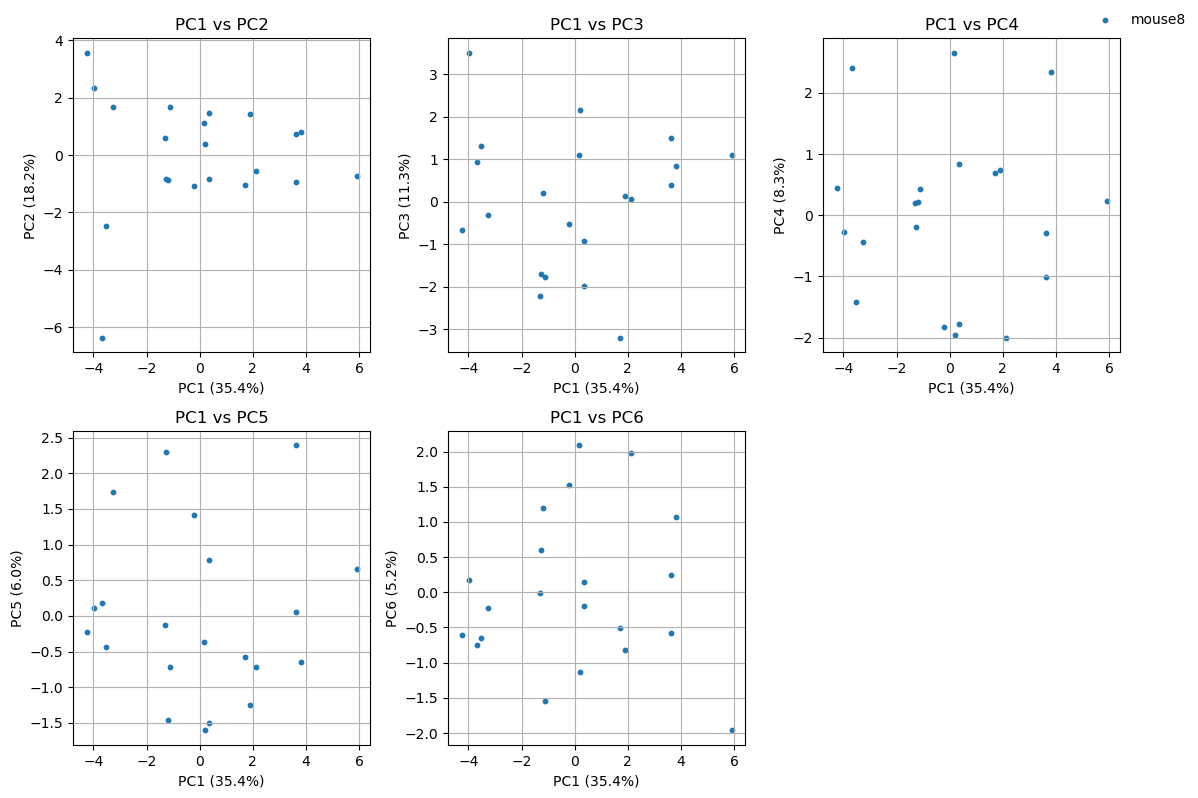

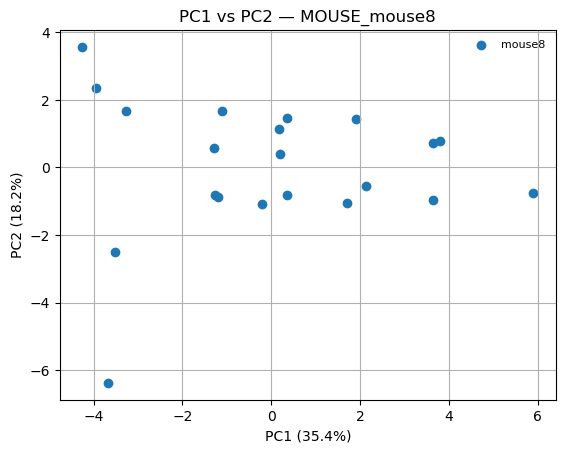

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/MOUSE_mouse8


,PC,feature,loading,abs_loading,rank
0,1,theta_bw_Hz,0.320466,0.320466,1
1,1,theta_peak_power_raw,-0.319742,0.319742,2
2,1,peak_global_power_raw,-0.319742,0.319742,3
3,1,theta_none,-0.301269,0.301269,4
4,1,delta_none,0.301132,0.301132,5
5,1,hgamma_none,-0.288591,0.288591,6
6,1,peak_global_freq_Hz,-0.278535,0.278535,7
7,1,theta_peak_Hz,-0.278535,0.278535,8
8,1,theta_peak_sd,0.261573,0.261573,9
9,1,hgamma_peak_power_raw,-0.205771,0.205771,10


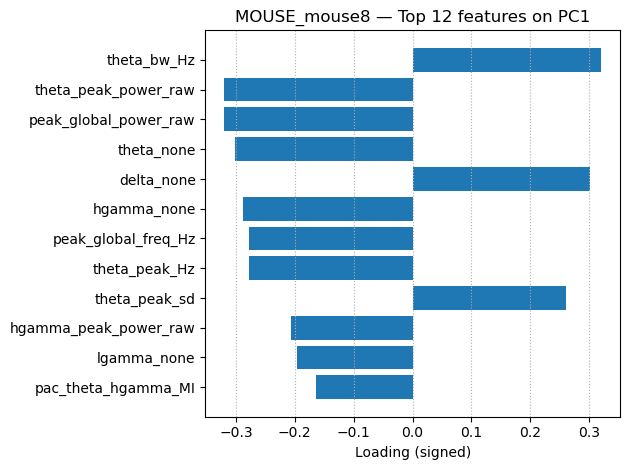

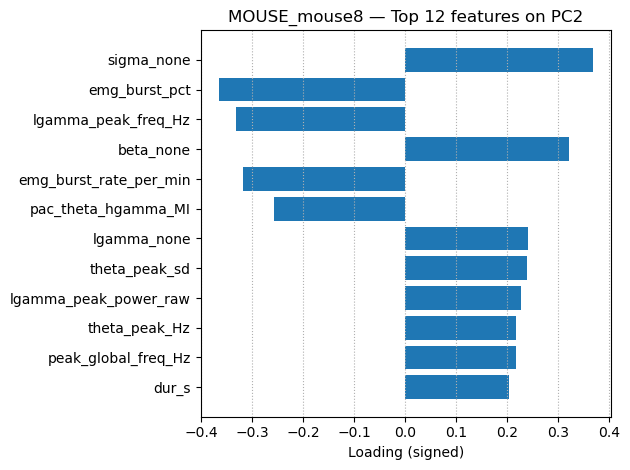

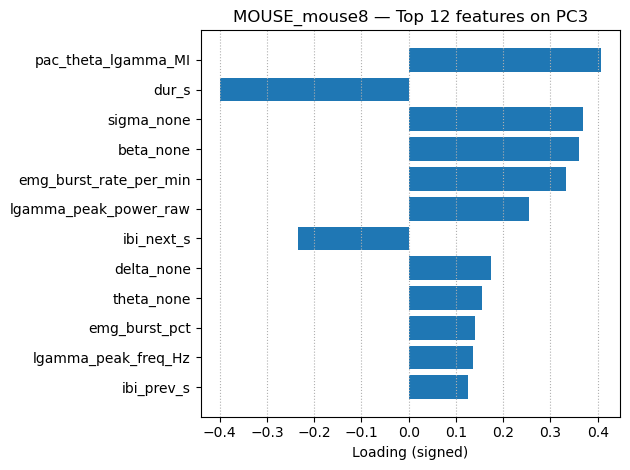

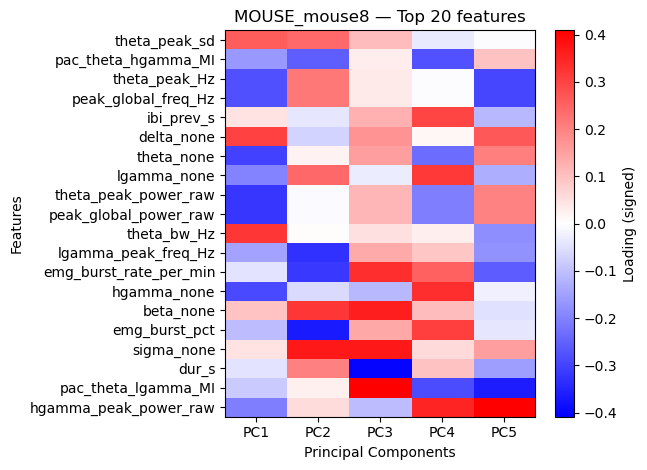

Best PC pair (by explained%): PC1, PC2  —  35.36% + 18.17% = 53.53%


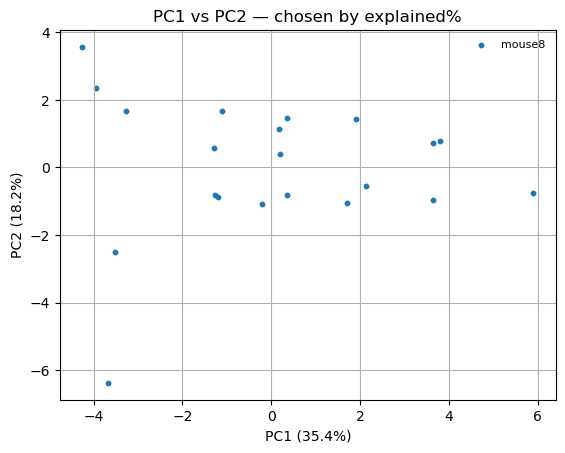

,rank,feature,loading_PC1,loading_PC2,combined_abs
0,1,emg_burst_pct,-0.107684,-0.364897,0.380454
1,2,sigma_none,0.044945,0.367481,0.370219
2,3,lgamma_peak_freq_Hz,-0.146770,-0.331318,0.362371
3,4,theta_peak_sd,0.261573,0.237949,0.353611
4,5,peak_global_freq_Hz,-0.278535,0.216121,0.352548
5,6,theta_peak_Hz,-0.278535,0.216121,0.352548
6,7,beta_none,0.093538,0.320520,0.333890
7,8,emg_burst_rate_per_min,-0.044477,-0.318889,0.321976
8,9,theta_bw_Hz,0.320466,0.004717,0.320500
9,10,peak_global_power_raw,-0.319742,-0.009518,0.319883


In [8]:
# Per-mouse PCA using per-mouse normalized data
# (falls back to ALL if ALL_ZM isn't defined)
BASE = ALL_ZM if 'ALL_ZM' in globals() else ALL

from IPython.display import display  # in case you haven't imported it

for m in sorted(BASE['mouse'].unique()):
    sub = BASE[BASE['mouse'] == m].copy()   # <-- FIX: subset by mouse m
    if len(sub) < 3:
        print(f"[SKIP] {m}: <3 rows")
        continue

    # We've already z-scored within-mouse in ALL_ZM, so skip re-scaling here
    X, feat_names = clean_numeric(sub, scale=False)  # <-- scale=False prevents double-standardizing
    if X.size == 0 or X.shape[1] < 2:
        print(f"[SKIP] {m}: <2 usable features")
        continue

    scores, loadings, explained = run_pca_simple(X)

    scree_plot(explained, f"Scree — MOUSE_{m}")

    # --- new: choose n PCs by cumulative explained + pair-grid like ALL ---
    n_pcs = choose_n_pcs_by_cum(explained, threshold=80.0)
    print(f"Number of PCs to reach 80% cum. explained (mouse {m}): {n_pcs}")
    labels = sub['condition'].astype(str).values
    if pd.unique(labels).size == 1:
        labels = sub['mouse'].astype(str).values
    # plot PC pairs up to n_pcs (safe-guard at least 2)
    if n_pcs >= 2:
        plot_pc_pair_grid(scores, explained, labels, pcs=list(range(1, n_pcs+1)), per_row=3,
                          figsize=(12, 4*int(np.ceil(max(1, (n_pcs-1))/3))))

    # Color by condition within this mouse
    pc_scatter(scores, explained, labels, f"PC1 vs PC2 — MOUSE_{m}")

    save_outputs(
        OUT_ROOT / f"MOUSE_{m}", f"MOUSE_{m}",
        scores, loadings, explained, feat_names,
        sub[["source_file","mouse","condition"]]
    )

    # Top contributors: table + bars + heatmap
    tbl_m = save_top_loadings_csv(OUT_ROOT / f"MOUSE_{m}", f"MOUSE_{m}", loadings, feat_names, k=12)
    display(tbl_m.head(24))

    for pc in range(1, min(4, loadings.shape[1] + 1)):
        plot_top_loadings_bar(loadings, feat_names, pc=pc, k=12, title_prefix=f"MOUSE_{m} —")

    plot_pc_feature_heatmap(
        loadings=loadings,
        feat_names=feat_names,
        title=f"MOUSE_{m}",
        out_path=OUT_ROOT / f"MOUSE_{m}" / "pc_feature_heatmap.png",
        top_n=20,
        pcs=list(range(1, min(6, loadings.shape[1] + 1)))
    )
# pick best pair by explained variance and plot it
best_pcs = choose_best_pc_pair(explained)             # returns (i, j), 1-based
print(f"Best PC pair (by explained%): PC{best_pcs[0]}, PC{best_pcs[1]}  —  "
      f"{explained[best_pcs[0]-1]:.2f}% + {explained[best_pcs[1]-1]:.2f}% = "
      f"{explained[best_pcs[0]-1] + explained[best_pcs[1]-1]:.2f}%")

# scatter of best pair
labels_local = (ALL_ZM['condition'].astype(str).values if 'ALL_ZM' in globals() else ALL['condition'].astype(str).values) \
               if 'ALL' in globals() and 'ALL_ZM' in globals() else labels
# adjust labels variable name depending on context (ALL / per-mouse / per-condition)
pc_scatter_pair(scores, explained, labels, pcs=best_pcs,
                title=f"PC{best_pcs[0]} vs PC{best_pcs[1]} — chosen by explained%")

# list + save top contributing features for that pair
tbl_pair = save_pair_top_features(OUT_ROOT / "ALL", "ALL", loadings, feat_names, pcs=best_pcs, k=20)
display(tbl_pair.head(20))


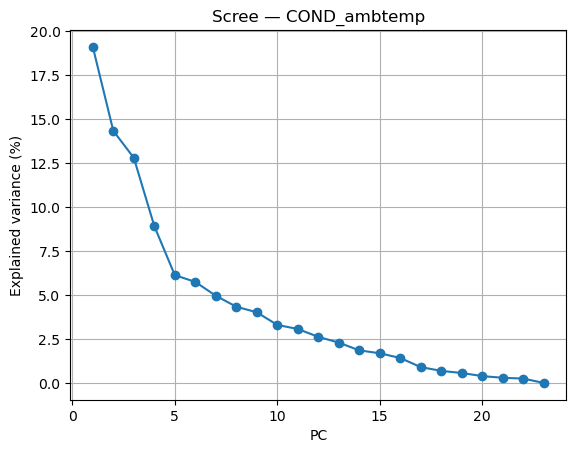

Number of PCs to reach 80% cum. explained (cond ambtemp): 9


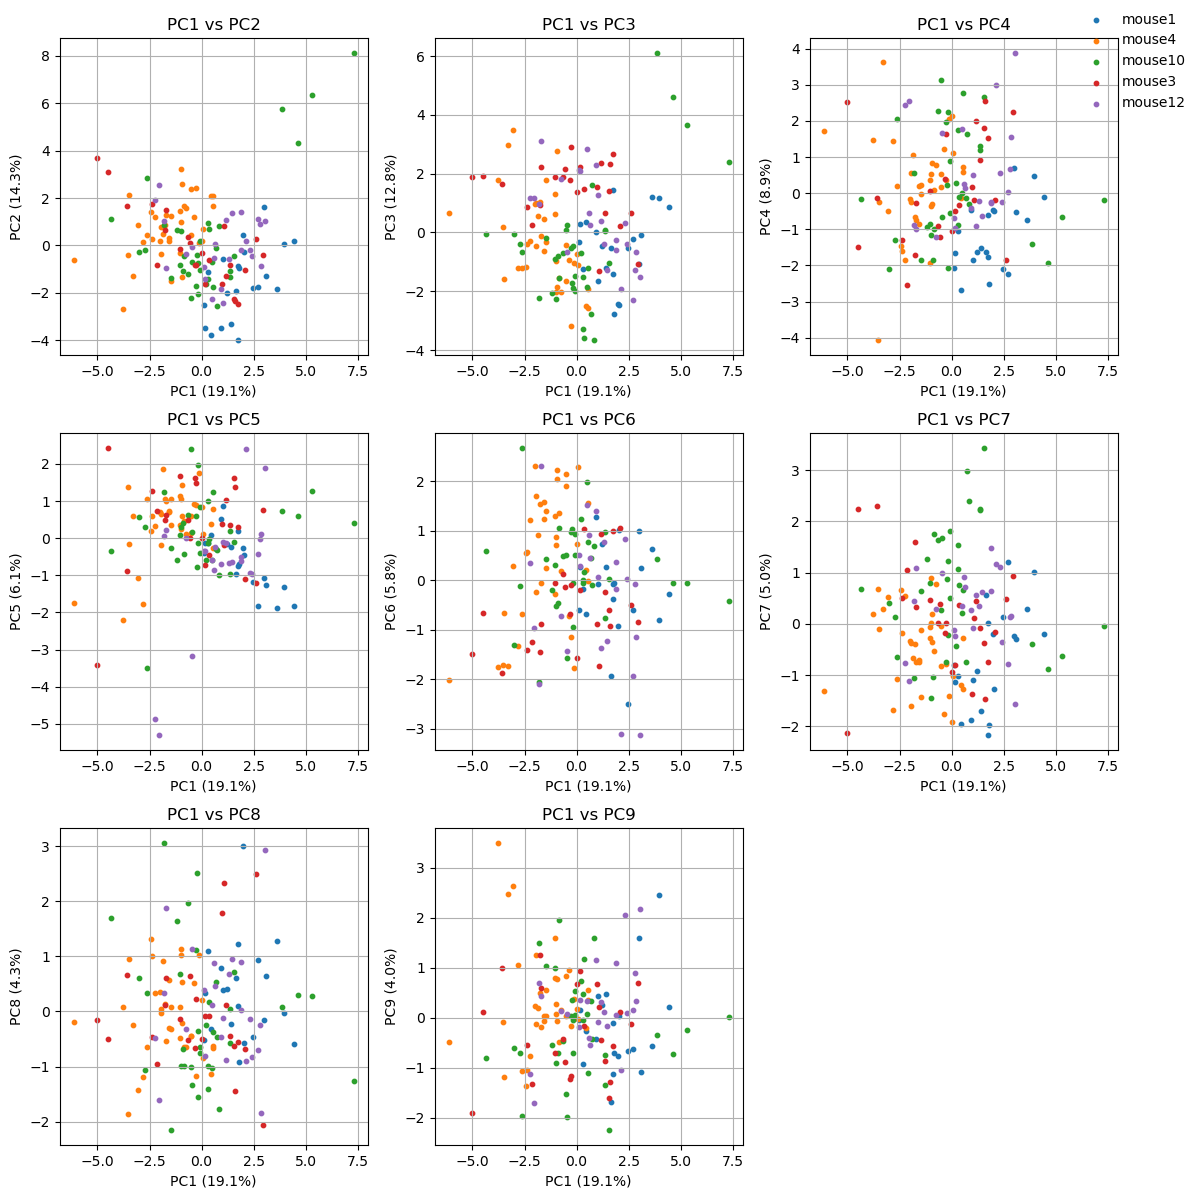

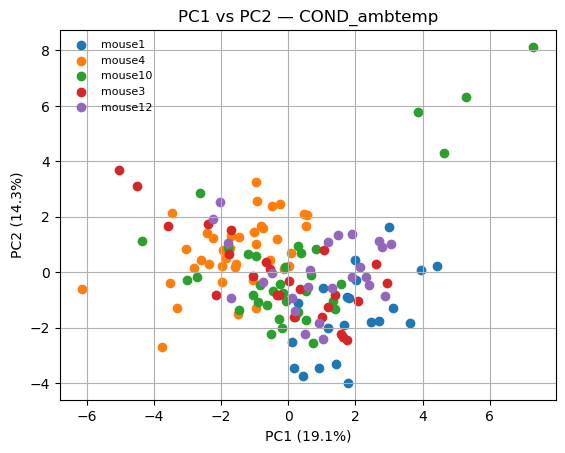

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/COND_ambtemp


,PC,feature,loading,abs_loading,rank
0,1,peak_global_freq_Hz,0.408947,0.408947,1
1,1,delta_none,-0.370915,0.370915,2
2,1,sigma_none,-0.333780,0.333780,3
3,1,lgamma_peak_freq_Hz,0.320779,0.320779,4
4,1,theta_peak_sd,-0.287080,0.287080,5
5,1,beta_none,-0.283536,0.283536,6
6,1,hgamma_peak_power_raw,0.242932,0.242932,7
7,1,lgamma_none,0.200457,0.200457,8
8,1,lgamma_peak_power_raw,0.191121,0.191121,9
9,1,pac_theta_lgamma_MI,-0.189355,0.189355,10


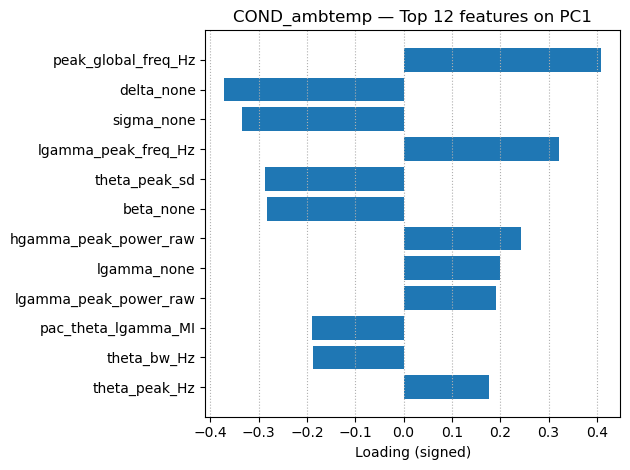

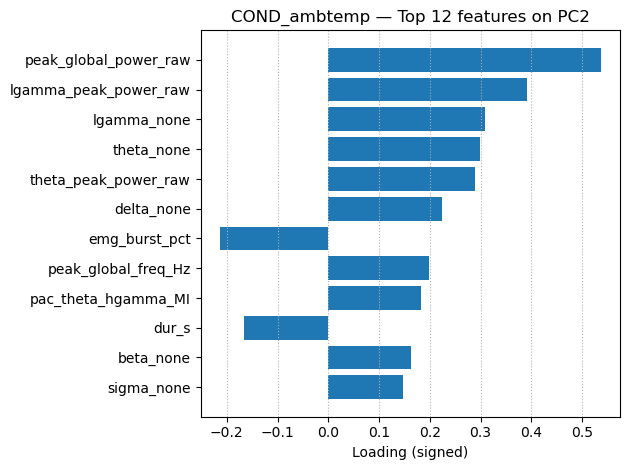

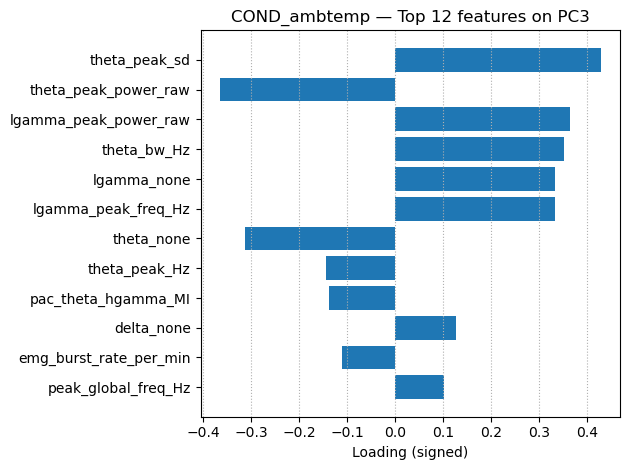

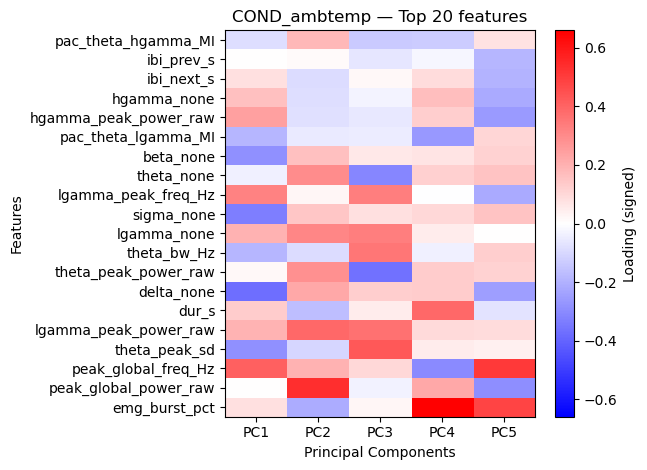

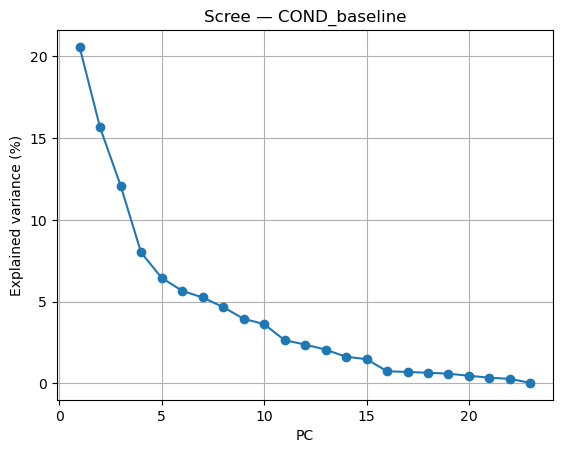

Number of PCs to reach 80% cum. explained (cond baseline): 9


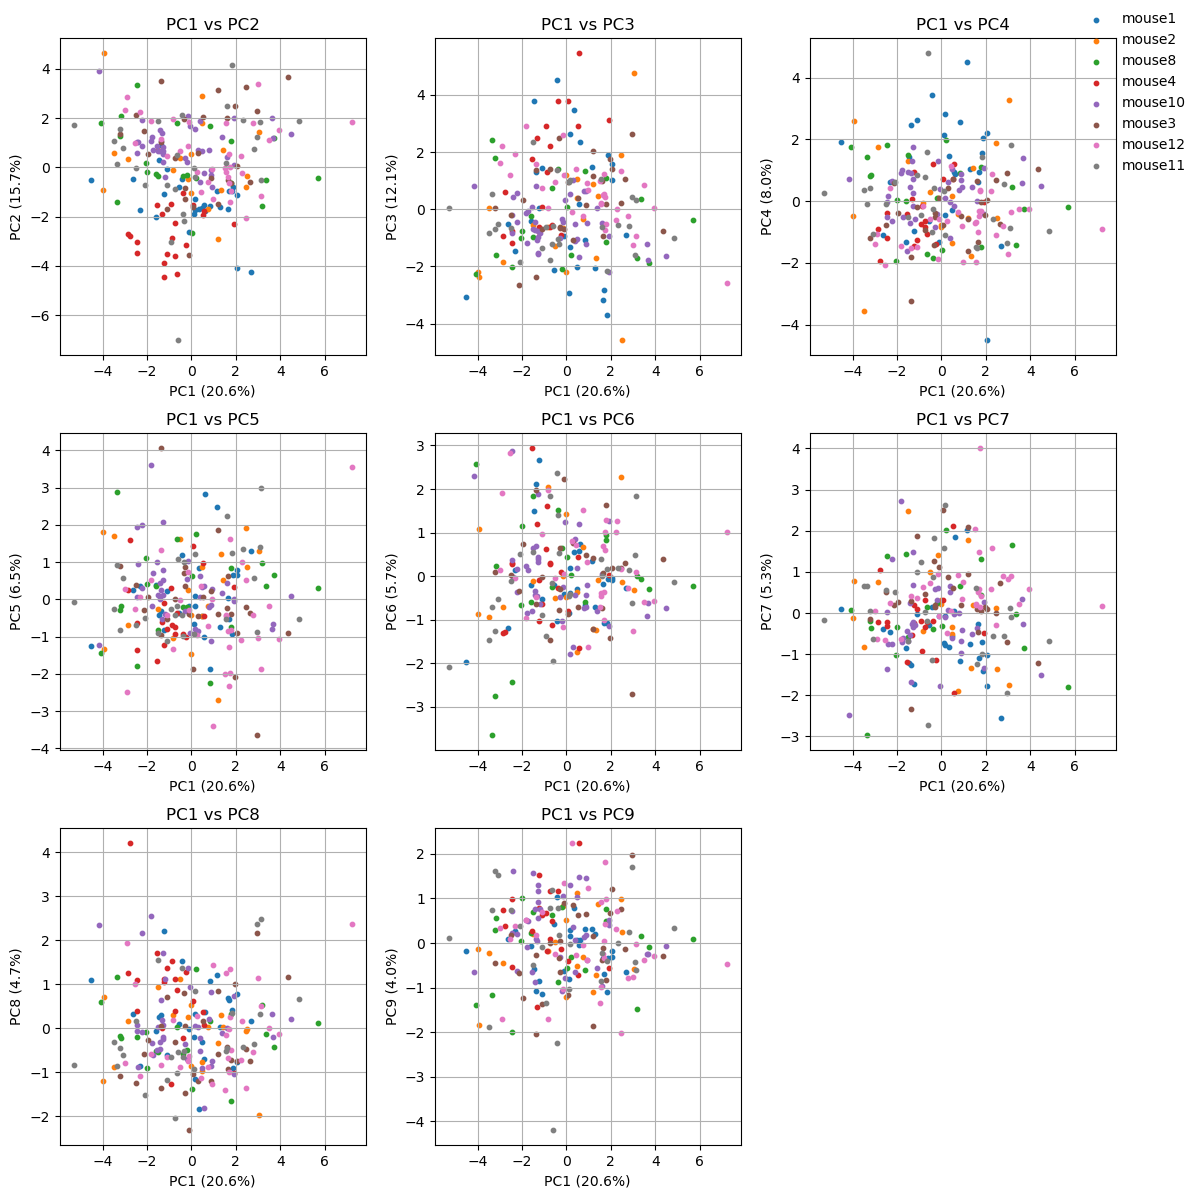

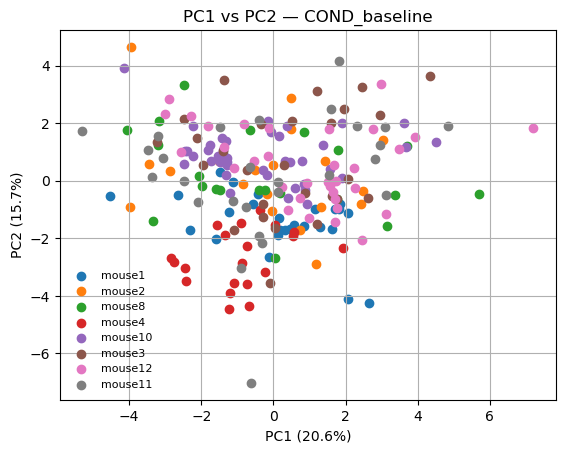

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/COND_baseline


,PC,feature,loading,abs_loading,rank
0,1,theta_peak_sd,0.378991,0.378991,1
1,1,theta_peak_Hz,-0.322648,0.322648,2
2,1,theta_bw_Hz,0.319127,0.319127,3
3,1,delta_none,0.309714,0.309714,4
4,1,hgamma_peak_power_raw,-0.275234,0.275234,5
5,1,theta_peak_power_raw,-0.269702,0.269702,6
6,1,hgamma_none,-0.254942,0.254942,7
7,1,sigma_none,0.250458,0.250458,8
8,1,theta_none,-0.212831,0.212831,9
9,1,peak_global_freq_Hz,-0.209494,0.209494,10


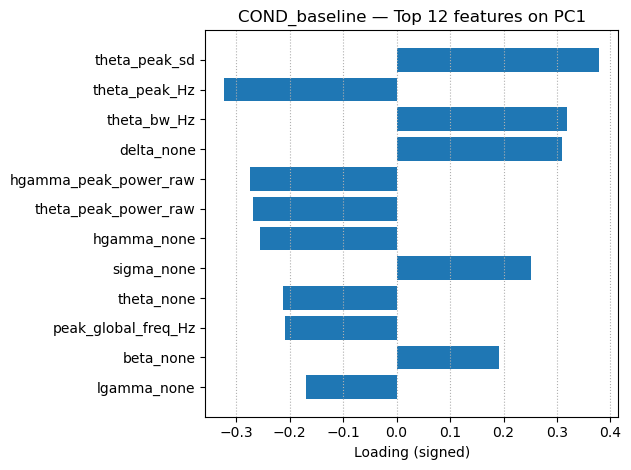

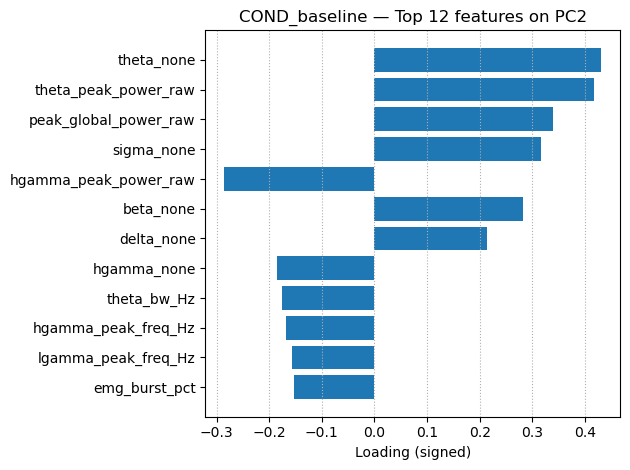

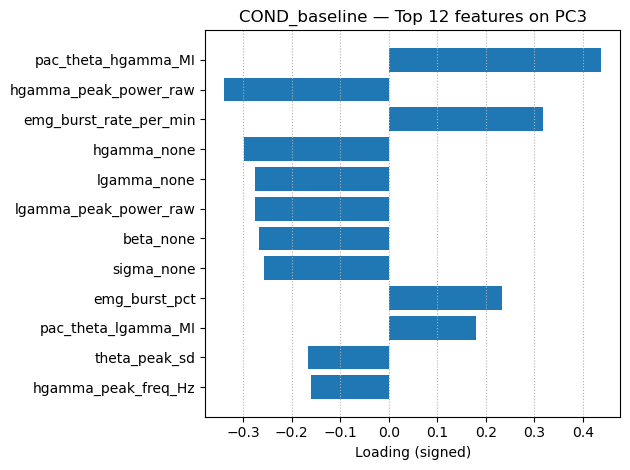

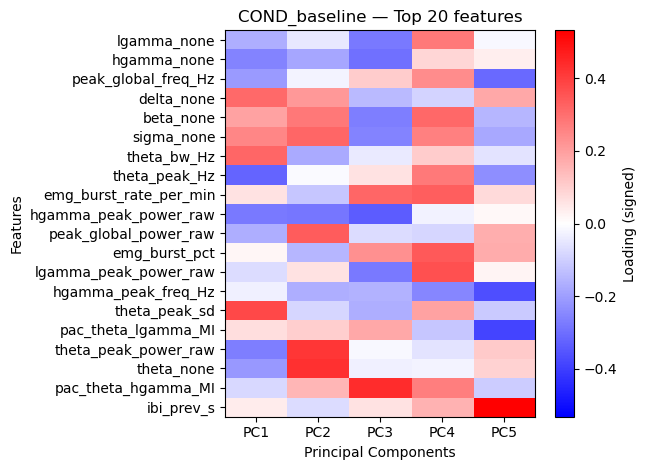

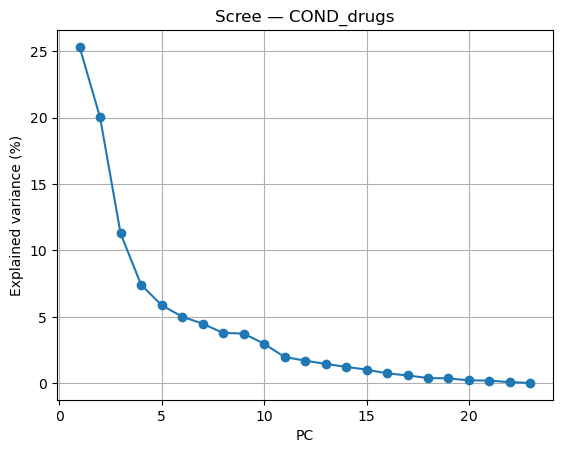

Number of PCs to reach 80% cum. explained (cond drugs): 8


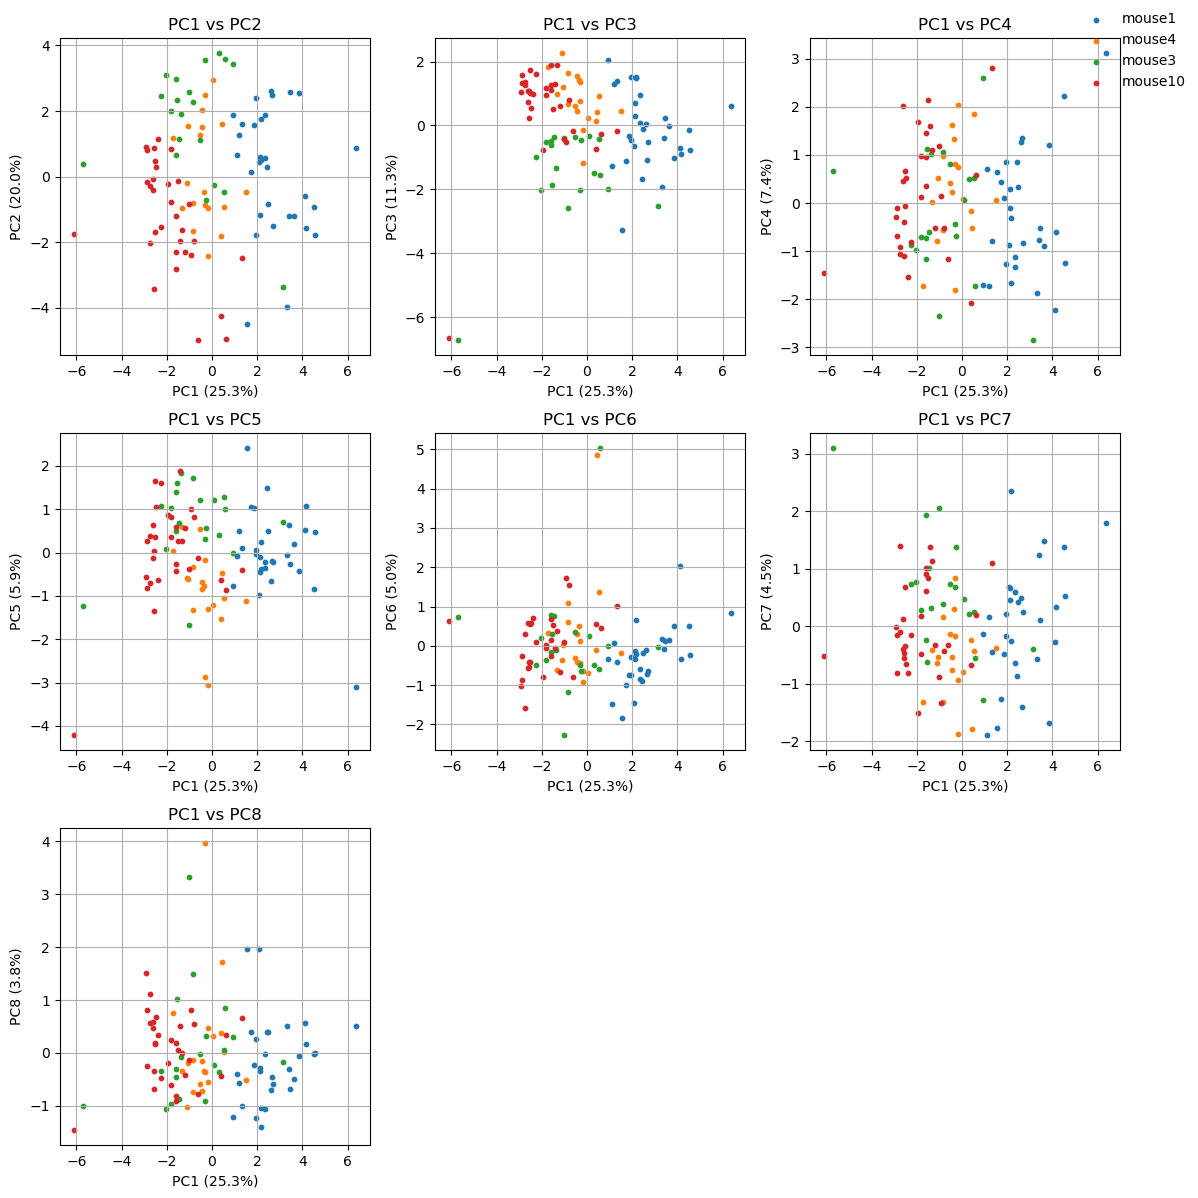

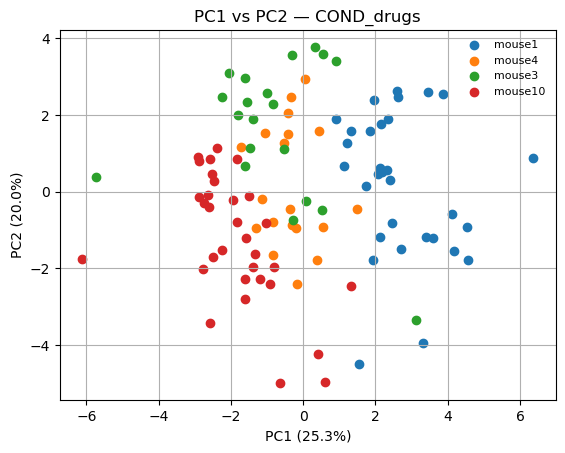

Saved: /Users/margaridaseabra/Downloads/REM analysis-results/COND_drugs


,PC,feature,loading,abs_loading,rank
0,1,beta_none,0.412507,0.412507,1
1,1,theta_none,0.411519,0.411519,2
2,1,sigma_none,0.393659,0.393659,3
3,1,theta_peak_power_raw,0.361791,0.361791,4
4,1,delta_none,0.313215,0.313215,5
5,1,peak_global_power_raw,0.286316,0.286316,6
6,1,hgamma_peak_freq_Hz,-0.281121,0.281121,7
7,1,emg_burst_rate_per_min,-0.147645,0.147645,8
8,1,pac_theta_lgamma_MI,0.136333,0.136333,9
9,1,dur_s,-0.117504,0.117504,10


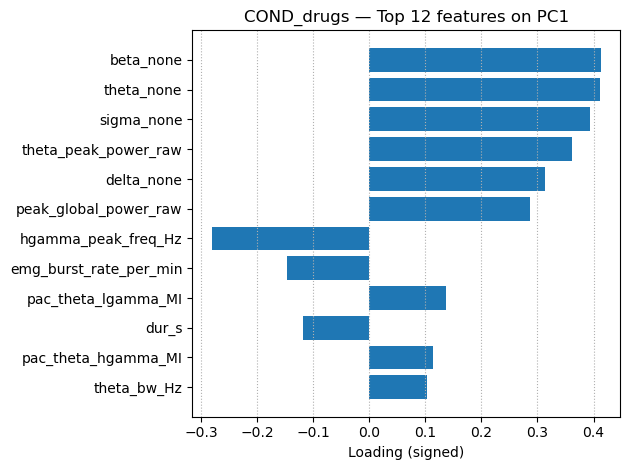

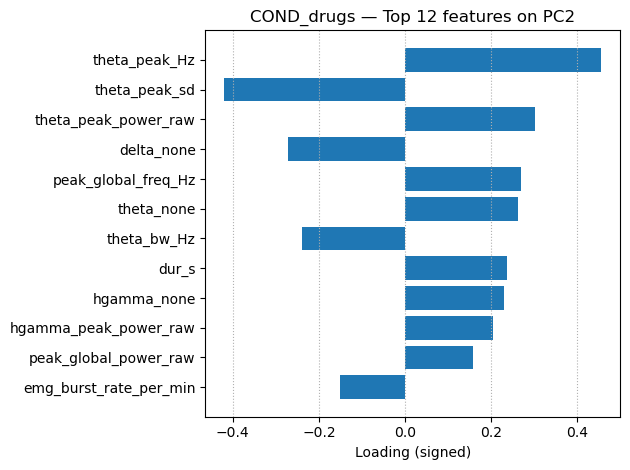

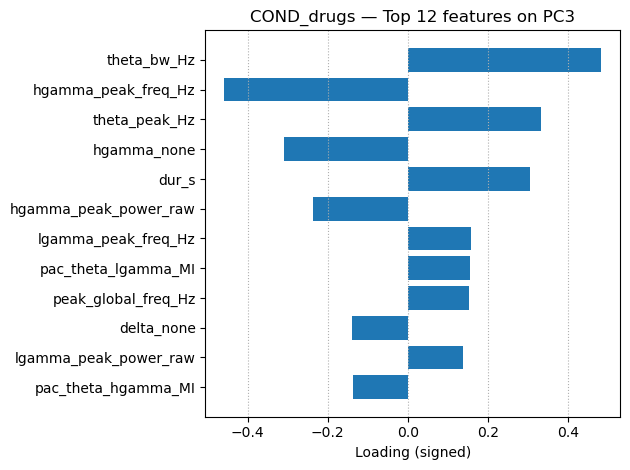

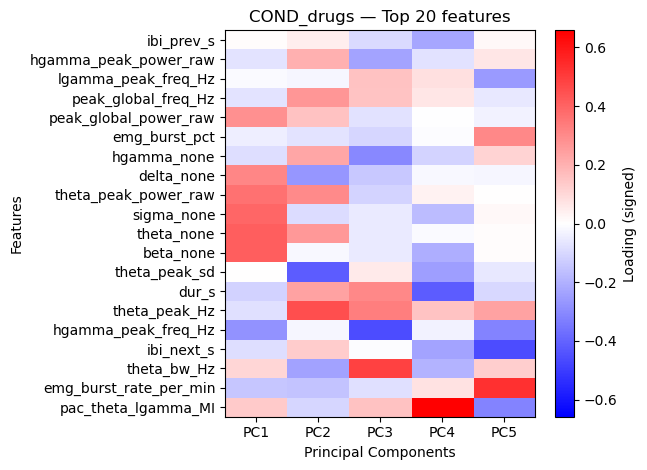

In [9]:
# Per-condition PCA (using per-mouse normalized data)
BASE = ALL_ZM if 'ALL_ZM' in globals() else ALL

for c in sorted(BASE['condition'].unique()):
    sub = BASE[BASE['condition'] == c].copy()
    if len(sub) < 3:
        print(f"[SKIP] {c}: <3 rows")
        continue
    X, feat_names = clean_numeric(sub, scale=False)
    if X.size == 0 or X.shape[1] < 2:
        print(f"[SKIP] {c}: <2 usable features")
        continue

    scores, loadings, explained = run_pca_simple(X)
    scree_plot(explained, f"Scree — COND_{c}")

    # --- new: choose n PCs by cumulative explained + pair-grid like ALL ---
    n_pcs = choose_n_pcs_by_cum(explained, threshold=80.0)
    print(f"Number of PCs to reach 80% cum. explained (cond {c}): {n_pcs}")
    labels = sub['mouse'].astype(str).values
    if pd.unique(labels).size == 1:
        labels = sub['condition'].astype(str).values
    if n_pcs >= 2:
        plot_pc_pair_grid(scores, explained, labels, pcs=list(range(1, n_pcs+1)), per_row=3,
                          figsize=(12, 4*int(np.ceil(max(1, (n_pcs-1))/3))))


    labels = sub['mouse'].astype(str).values
    if pd.unique(labels).size == 1:
        labels = sub['condition'].astype(str).values
    pc_scatter(scores, explained, labels, f"PC1 vs PC2 — COND_{c}")

    save_outputs(OUT_ROOT / f"COND_{c}", f"COND_{c}", scores, loadings, explained, feat_names,
                 sub[["source_file","mouse","condition"]])

    tbl_c = save_top_loadings_csv(OUT_ROOT / f"COND_{c}", f"COND_{c}", loadings, feat_names, k=12)
    display(tbl_c.head(24))

    for pc in range(1, min(4, loadings.shape[1] + 1)):
        plot_top_loadings_bar(loadings, feat_names, pc=pc, k=12, title_prefix=f"COND_{c} —")

    plot_pc_feature_heatmap(
        loadings=loadings,
        feat_names=feat_names,
        title=f"COND_{c}",
        out_path=OUT_ROOT / f"COND_{c}" / "pc_feature_heatmap.png",
        top_n=20,
        pcs=list(range(1, min(6, loadings.shape[1] + 1)))
    )

